# Dataset Loading

In [1]:
import os
import pandas as pd

dataset_path = r"D:\Projects\Client Projects\Implementation\4031\Dataset"

video_extensions = {
    ".mp4", ".avi", ".mov", ".mkv",
    ".wmv", ".flv", ".webm", ".m4v"
}

csv_extension = ".csv"

video_files = []
csv_files = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:
        file_path = os.path.join(root, file)
        extension = os.path.splitext(file)[1].lower()

        if extension in video_extensions:
            video_files.append(file_path)

        elif extension == csv_extension:
            csv_files.append(file_path)

print("=" * 80)
print("VIDEO DATASET INFORMATION")
print("=" * 80)

print(f"Total Videos : {len(video_files)}")

print("\n" + "=" * 80)
print("CSV DATASET INFORMATION")
print("=" * 80)

print(f"\nTotal CSV Files : {len(csv_files)}")

if len(csv_files) > 0:

    for i, csv_file in enumerate(csv_files, start=1):

        try:

            df = pd.read_csv(csv_file)

            print(f"\nRows    : {df.shape[0]}")
            print(f"Columns : {df.shape[1]}")

            print("\nColumn Names:")
            for j, column in enumerate(df.columns, start=1):
                print(f"  {j:02d}. {column}")

            print("\nData Types:")
            print(df.dtypes.to_string())

            print("\nMissing Values:")
            missing = df.isnull().sum()

            if missing.sum() == 0:
                print("  No missing values")
            else:
                print(missing[missing > 0].to_string())

            print(f"\nDuplicate Rows : {df.duplicated().sum()}")

            print("\nFirst 5 Rows:")
            print(df.head())

        except Exception as e:

            print(f"\nError loading CSV:")
            print(e)

else:
    print("\nNo CSV files found.")

VIDEO DATASET INFORMATION
Total Videos : 223

CSV DATASET INFORMATION

Total CSV Files : 1

Rows    : 4000
Columns : 36

Column Names:
  01. Sequence_ID
  02. Performer_ID
  03. Dance_Style
  04. Timestamp_ms
  05. Accel_X
  06. Accel_Y
  07. Accel_Z
  08. Gyro_X
  09. Gyro_Y
  10. Gyro_Z
  11. Orientation_Pitch
  12. Orientation_Roll
  13. Orientation_Yaw
  14. Joint_Head_X
  15. Joint_Head_Y
  16. Joint_Head_Z
  17. Joint_HandLeft_X
  18. Joint_HandLeft_Y
  19. Joint_HandLeft_Z
  20. Joint_HandRight_X
  21. Joint_HandRight_Y
  22. Joint_HandRight_Z
  23. Joint_FootLeft_X
  24. Joint_FootLeft_Y
  25. Joint_FootLeft_Z
  26. Joint_FootRight_X
  27. Joint_FootRight_Y
  28. Joint_FootRight_Z
  29. Tempo_BPM
  30. Rhythm_Score
  31. MFMD_Feature_1
  32. MFMD_Feature_2
  33. Kinematic_Embedding_1
  34. Kinematic_Embedding_2
  35. Motion_Label
  36. Generated_Sequence_Quality

Data Types:
Sequence_ID                    object
Performer_ID                   object
Dance_Style                 

# Preprocessing - Temporal Savitzky–Golay filtering, Min–Max normalization and Temporal segmentation

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
from collections import deque
from scipy.signal import savgol_coeffs
from sklearn.preprocessing import MinMaxScaler

DATASET_PATH = r"D:\Projects\Client Projects\Implementation\4031\Dataset"

OUTPUT_PATH = r"D:\Projects\Client Projects\Implementation\4031\Output"

os.makedirs(OUTPUT_PATH, exist_ok=True)

SG_WINDOW_LENGTH = 7
SG_POLYORDER = 2

WINDOW_SIZE = 32
STEP_SIZE = 16

video_extensions = {
    ".mp4",
    ".avi",
    ".mov",
    ".mkv",
    ".wmv",
    ".flv",
    ".webm",
    ".m4v"
}

video_files = []
csv_files = []

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        file_path = os.path.join(root, file)

        extension = os.path.splitext(file)[1].lower()

        if extension in video_extensions:
            video_files.append(file_path)

        elif extension == ".csv":
            csv_files.append(file_path)

if len(video_files) == 0:
    raise FileNotFoundError(
        "No video file was found."
    )

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file was found."
    )

input_video = video_files[0]
input_csv = csv_files[0]

print("\n" + "=" * 80)
print("VIDEO PREPROCESSING - STREAMING SAVITZKY-GOLAY FILTER")
print("=" * 80)


cap = cv2.VideoCapture(input_video)

if not cap.isOpened():
    raise RuntimeError(
        "Unable to open input video."
    )


fps = cap.get(cv2.CAP_PROP_FPS)

frame_width = int(
    cap.get(cv2.CAP_PROP_FRAME_WIDTH)
)

frame_height = int(
    cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
)

total_frames = int(
    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

if SG_WINDOW_LENGTH % 2 == 0:

    raise ValueError(
        "SG_WINDOW_LENGTH must be an odd number."
    )

if SG_WINDOW_LENGTH <= SG_POLYORDER:

    raise ValueError(
        "SG_WINDOW_LENGTH must be greater than "
        "SG_POLYORDER."
    )

if total_frames < SG_WINDOW_LENGTH:

    raise ValueError(
        "Video contains fewer frames than the "
        "Savitzky-Golay window."
    )

sg_coefficients = savgol_coeffs(
    window_length=SG_WINDOW_LENGTH,
    polyorder=SG_POLYORDER,
    deriv=0,
    delta=1.0,
    use="conv"
)

sg_coefficients = sg_coefficients.astype(
    np.float32
)

print("\nSavitzky-Golay Coefficients:")

for i, coefficient in enumerate(
    sg_coefficients
):

    print(
        f"  Coefficient {i + 1}: "
        f"{coefficient:.8f}"
    )

output_video = os.path.join(
    OUTPUT_PATH,
    "Preprocessed_SGF_Dance_Video.mp4"
)

# MP4 codec
fourcc = cv2.VideoWriter_fourcc(
    *"mp4v"
)

writer = cv2.VideoWriter(
    output_video,
    fourcc,
    fps,
    (frame_width, frame_height)
)

if not writer.isOpened():

    cap.release()

    raise RuntimeError(
        "Unable to create output video."
    )

half_window = SG_WINDOW_LENGTH // 2

buffer = deque(
    maxlen=SG_WINDOW_LENGTH
)

ret, first_frame = cap.read()

if not ret:

    cap.release()
    writer.release()

    raise RuntimeError(
        "Unable to read first video frame."
    )

buffer.append(
    first_frame
)

for _ in range(half_window):

    buffer.append(
        first_frame.copy()
    )

for _ in range(half_window):

    ret, frame = cap.read()

    if not ret:
        break

    buffer.append(frame)

def apply_sg_window(frame_buffer, coefficients):

    accumulator = np.zeros_like(
        frame_buffer[0],
        dtype=np.float32
    )

    for frame, coefficient in zip(
        frame_buffer,
        coefficients
    ):

        accumulator += (
            frame.astype(np.float32)
            * coefficient
        )

    accumulator = np.clip(
        accumulator,
        0,
        255
    )

    return accumulator.astype(
        np.uint8
    )

filtered_frame = apply_sg_window(
    list(buffer),
    sg_coefficients
)

writer.write(
    filtered_frame
)

processed_frames = 1

while True:

    ret, frame = cap.read()

    if not ret:
        break

    buffer.append(frame)

    if len(buffer) == SG_WINDOW_LENGTH:

        filtered_frame = apply_sg_window(
            list(buffer),
            sg_coefficients
        )

        writer.write(
            filtered_frame
        )

        processed_frames += 1


if len(buffer) == SG_WINDOW_LENGTH:

    last_frame = buffer[-1]

    # Generate the remaining half-window outputs.
    for _ in range(half_window):

        buffer.append(
            last_frame.copy()
        )

        filtered_frame = apply_sg_window(
            list(buffer),
            sg_coefficients
        )

        writer.write(
            filtered_frame
        )

        processed_frames += 1

cap.release()
writer.release()


print("\n" + "-" * 80)
print("VIDEO PREPROCESSING COMPLETED")
print("-" * 80)

print("\n" + "=" * 80)
print("CSV PREPROCESSING")
print("=" * 80)

df = pd.read_csv(
    input_csv
)

duplicate_count = df.duplicated().sum()

print(
    f"\nDuplicate Rows : {duplicate_count}"
)

if duplicate_count > 0:

    df = (
        df
        .drop_duplicates()
        .reset_index(drop=True)
    )

print(
    f"Rows After Duplicate Removal : "
    f"{len(df)}"
)

numeric_columns = df.select_dtypes(
    include=[np.number]
).columns.tolist()


for column in numeric_columns:

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

missing_before = df.isnull().sum().sum()

print(
    f"\nMissing Values Before Handling : "
    f"{missing_before}"
)


for column in numeric_columns:

    if df[column].isnull().sum() > 0:

        median_value = df[column].median()

        df[column] = df[column].fillna(
            median_value
        )


missing_after = df.isnull().sum().sum()

print(
    f"Missing Values After Handling  : "
    f"{missing_after}"
)

if "Timestamp_ms" in df.columns:

    df = df.sort_values(
        by="Timestamp_ms"
    ).reset_index(
        drop=True
    )

metadata_columns = [
    "Sequence_ID",
    "Performer_ID",
    "Timestamp_ms"
]

target_columns = [
    "Dance_Style",
    "Motion_Label",
    "Generated_Sequence_Quality"
]

numeric_columns = df.select_dtypes(
    include=[np.number]
).columns.tolist()

normalization_columns = [
    column
    for column in numeric_columns
    if column not in metadata_columns
    and column != "Generated_Sequence_Quality"
]

print("\n" + "=" * 80)
print("MIN-MAX NORMALIZATION")
print("=" * 80)

scaler = MinMaxScaler(
    feature_range=(0, 1)
)

df_preprocessed = df.copy()

df_preprocessed[
    normalization_columns
] = scaler.fit_transform(
    df_preprocessed[
        normalization_columns
    ]
)

print(
    "\nMin-Max normalization completed."
)

print(
    "Normalized range: [0, 1]"
)

normalization_parameters = []

for index, column in enumerate(
    normalization_columns
):

    normalization_parameters.append({

        "Feature": column,

        "Original_Min":
            scaler.data_min_[index],

        "Original_Max":
            scaler.data_max_[index],

        "Scale":
            scaler.scale_[index],

        "Output_Min": 0.0,

        "Output_Max": 1.0
    })


normalization_df = pd.DataFrame(
    normalization_parameters
)

normalization_file = os.path.join(
    OUTPUT_PATH,
    "MinMax_Normalization_Parameters.csv"
)

normalization_df.to_csv(
    normalization_file,
    index=False
)

print("\n" + "=" * 80)
print("TEMPORAL WINDOW SEGMENTATION")
print("=" * 80)

print(
    f"Window Size : {WINDOW_SIZE}"
)

print(
    f"Step Size   : {STEP_SIZE}"
)

overlap_percentage = (
    (WINDOW_SIZE - STEP_SIZE)
    / WINDOW_SIZE
) * 100

if "Sequence_ID" in df_preprocessed.columns:

    sequence_counts = (
        df_preprocessed[
            "Sequence_ID"
        ]
        .value_counts()
    )

    unique_sequences = (
        df_preprocessed[
            "Sequence_ID"
        ]
        .nunique()
    )

    maximum_sequence_length = (
        sequence_counts.max()
    )

else:

    sequence_counts = None
    maximum_sequence_length = 0

windows = []

window_counter = 0


if (
    "Sequence_ID" in df_preprocessed.columns
    and maximum_sequence_length >= WINDOW_SIZE
):

    print(
        "\nUsing Sequence_ID-based "
        "temporal segmentation."
    )

    grouped_data = (
        df_preprocessed
        .groupby(
            "Sequence_ID",
            sort=False
        )
    )

    for sequence_id, group in grouped_data:

        group = (
            group
            .sort_values(
                "Timestamp_ms"
            )
            .reset_index(
                drop=True
            )
        )

        n_rows = len(group)

        if n_rows < WINDOW_SIZE:
            continue

        for start in range(
            0,
            n_rows - WINDOW_SIZE + 1,
            STEP_SIZE
        ):

            end = (
                start + WINDOW_SIZE
            )

            window = group.iloc[
                start:end
            ].copy()

            window["Window_ID"] = (
                f"WIN_{window_counter:05d}"
            )

            window["Window_Position"] = (
                np.arange(
                    WINDOW_SIZE
                )
            )

            windows.append(
                window
            )

            window_counter += 1


else:

    print(
        "\nSequence_ID does not contain "
        "enough repeated observations "
        "for 32-sample windows."
    )

    print(
        "Using the complete timestamp-ordered "
        "motion data for temporal segmentation."
    )

    temporal_data = (
        df_preprocessed
        .sort_values(
            "Timestamp_ms"
        )
        .reset_index(
            drop=True
        )
    )

    n_rows = len(
        temporal_data
    )

    for start in range(
        0,
        n_rows - WINDOW_SIZE + 1,
        STEP_SIZE
    ):

        end = (
            start + WINDOW_SIZE
        )

        window = temporal_data.iloc[
            start:end
        ].copy()

        window["Window_ID"] = (
            f"WIN_{window_counter:05d}"
        )

        window["Window_Position"] = (
            np.arange(
                WINDOW_SIZE
            )
        )

        windows.append(
            window
        )

        window_counter += 1

if len(windows) == 0:

    raise RuntimeError(
        "No temporal windows were generated. "
        "Reduce WINDOW_SIZE."
    )

preprocessed_windowed_df = pd.concat(
    windows,
    ignore_index=True
)

output_csv = os.path.join(
    OUTPUT_PATH,
    "Preprocessed_Dance_Motion_Data.csv"
)

preprocessed_windowed_df.to_csv(
    output_csv,
    index=False
)

windows_directory = os.path.join(
    OUTPUT_PATH,
    "Temporal_Windows"
)

os.makedirs(
    windows_directory,
    exist_ok=True
)

for window_id, window_df in (
    preprocessed_windowed_df
    .groupby(
        "Window_ID",
        sort=False
    )
):

    window_file = os.path.join(
        windows_directory,
        f"{window_id}.csv"
    )

    window_df.to_csv(
        window_file,
        index=False
    )

print(
    windows_directory
)

print("PREPROCESSING COMPLETED SUCCESSFULLY")


VIDEO PREPROCESSING - STREAMING SAVITZKY-GOLAY FILTER

Savitzky-Golay Coefficients:
  Coefficient 1: -0.09523810
  Coefficient 2: 0.14285715
  Coefficient 3: 0.28571430
  Coefficient 4: 0.33333334
  Coefficient 5: 0.28571430
  Coefficient 6: 0.14285715
  Coefficient 7: -0.09523810

--------------------------------------------------------------------------------
VIDEO PREPROCESSING COMPLETED
--------------------------------------------------------------------------------

CSV PREPROCESSING

Duplicate Rows : 0
Rows After Duplicate Removal : 4000

Missing Values Before Handling : 0
Missing Values After Handling  : 0

MIN-MAX NORMALIZATION

Min-Max normalization completed.
Normalized range: [0, 1]

TEMPORAL WINDOW SEGMENTATION
Window Size : 32
Step Size   : 16

Sequence_ID does not contain enough repeated observations for 32-sample windows.
Using the complete timestamp-ordered motion data for temporal segmentation.
D:\Projects\Client Projects\Implementationă1\Output\Temporal_Windows
PREPR

# Feature Extraction - Mel-Frequency Motion Descriptors (MFMD) and skeletal kinematic embeddings 

In [3]:
import os
import glob
import warnings

import numpy as np
import pandas as pd

from scipy.signal import get_window
from scipy.fft import rfft, rfftfreq


warnings.filterwarnings("ignore")

WINDOW_DIRECTORY = (
    r"D:\Projects\Client Projects\Implementation\4031"
    r"\Output\Temporal_Windows"
)

OUTPUT_DIRECTORY = (
    r"D:\Projects\Client Projects\Implementation\4031"
    r"\Output"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIRECTORY,
    "MFMD_Skeletal_Kinematic_Features.csv"
)

os.makedirs(
    OUTPUT_DIRECTORY,
    exist_ok=True
)

N_MEL_BANDS = 8

EPSILON = 1e-8

WINDOW_TYPE = "hamming"

MFMD_COLUMNS = [
    "Accel_X",
    "Accel_Y",
    "Accel_Z",
    "Gyro_X",
    "Gyro_Y",
    "Gyro_Z",
    "Orientation_Pitch",
    "Orientation_Roll",
    "Orientation_Yaw",
    "Tempo_BPM",
    "Rhythm_Score"
]

JOINTS = {
    "Head": [
        "Joint_Head_X",
        "Joint_Head_Y",
        "Joint_Head_Z"
    ],

    "HandLeft": [
        "Joint_HandLeft_X",
        "Joint_HandLeft_Y",
        "Joint_HandLeft_Z"
    ],

    "HandRight": [
        "Joint_HandRight_X",
        "Joint_HandRight_Y",
        "Joint_HandRight_Z"
    ],

    "FootLeft": [
        "Joint_FootLeft_X",
        "Joint_FootLeft_Y",
        "Joint_FootLeft_Z"
    ],

    "FootRight": [
        "Joint_FootRight_X",
        "Joint_FootRight_Y",
        "Joint_FootRight_Z"
    ]
}

window_files = sorted(
    glob.glob(
        os.path.join(
            WINDOW_DIRECTORY,
            "*.csv"
        )
    )
)

if len(window_files) == 0:

    raise FileNotFoundError(
        "No temporal-window CSV files were found in:\n"
        + WINDOW_DIRECTORY
    )


print("=" * 80)
print("ESSO-DCTN FEATURE EXTRACTION")
print("=" * 80)

print(
    f"\nTotal Temporal Windows : "
    f"{len(window_files)}"
)

print(
    f"MFMD Bands             : "
    f"{N_MEL_BANDS}"
)

print(
    f"MFMD Window             : "
    f"{WINDOW_TYPE}"
)

def hz_to_mel(frequency):

    return 2595.0 * np.log10(
        1.0 + frequency / 700.0
    )


def mel_to_hz(mel):

    return 700.0 * (
        10.0 ** (mel / 2595.0) - 1.0
    )


def create_mel_filterbank(
    n_fft,
    n_mels,
    sample_rate
):

    """
    Create triangular Mel filter bank.

    The FFT here operates on temporally ordered
    motion samples. Since the source dataset does
    not provide a native sensor sampling frequency,
    the normalized frequency index is used for
    the motion representation.
    """

    n_frequency_bins = (
        n_fft // 2 + 1
    )

    minimum_frequency = 0.0

    maximum_frequency = (
        sample_rate / 2.0
    )

    minimum_mel = hz_to_mel(
        minimum_frequency
    )

    maximum_mel = hz_to_mel(
        maximum_frequency
    )

    mel_points = np.linspace(
        minimum_mel,
        maximum_mel,
        n_mels + 2
    )

    hz_points = mel_to_hz(
        mel_points
    )

    bin_indices = np.floor(
        (n_fft + 1)
        * hz_points
        / sample_rate
    ).astype(int)

    filter_bank = np.zeros(
        (
            n_mels,
            n_frequency_bins
        ),
        dtype=np.float32
    )

    for m in range(
        1,
        n_mels + 1
    ):

        left = bin_indices[m - 1]
        center = bin_indices[m]
        right = bin_indices[m + 1]

        left = max(
            0,
            min(
                left,
                n_frequency_bins - 1
            )
        )

        center = max(
            0,
            min(
                center,
                n_frequency_bins - 1
            )
        )

        right = max(
            0,
            min(
                right,
                n_frequency_bins - 1
            )
        )

        if center > left:

            for k in range(
                left,
                center
            ):

                filter_bank[
                    m - 1,
                    k
                ] = (
                    (k - left)
                    / float(center - left)
                )

        if right > center:

            for k in range(
                center,
                right
            ):

                filter_bank[
                    m - 1,
                    k
                ] = (
                    (right - k)
                    / float(right - center)
                )

    return filter_bank

def extract_mfmd(
    signal,
    feature_name,
    n_mels=N_MEL_BANDS
):

    signal = np.asarray(
        signal,
        dtype=np.float64
    )

    signal = np.nan_to_num(
        signal,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    n_samples = len(signal)

    if n_samples < 2:

        return {
            f"MFMD_{feature_name}_{i+1}": 0.0
            for i in range(n_mels)
        }

    signal = (
        signal
        - np.mean(signal)
    )

    hamming = get_window(
        WINDOW_TYPE,
        n_samples
    )

    windowed_signal = (
        signal * hamming
    )

    spectrum = rfft(
        windowed_signal
    )

    power_spectrum = (
        np.abs(spectrum) ** 2
    )

    sample_rate = float(
        n_samples
    )

    n_fft = n_samples

    filter_bank = create_mel_filterbank(
        n_fft=n_fft,
        n_mels=n_mels,
        sample_rate=sample_rate
    )

    mel_energy = np.dot(
        filter_bank,
        power_spectrum
    )

    mfmd = np.log(
        mel_energy + EPSILON
    )

    mfmd = np.nan_to_num(
        mfmd,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    features = {}

    for i, value in enumerate(
        mfmd
    ):

        features[
            f"MFMD_{feature_name}_{i+1}"
        ] = float(value)

    return features

def extract_kinematic_features(df):

    features = {}

    joint_positions = {}

    for joint_name, columns in JOINTS.items():

        if not all(
            column in df.columns
            for column in columns
        ):

            continue

        joint_positions[
            joint_name
        ] = df[
            columns
        ].values.astype(
            np.float64
        )

    joint_names = list(
        joint_positions.keys()
    )

    distance_arrays = {}

    for i in range(
        len(joint_names)
    ):

        for j in range(
            i + 1,
            len(joint_names)
        ):

            joint_1 = joint_names[i]
            joint_2 = joint_names[j]

            coordinates_1 = (
                joint_positions[joint_1]
            )

            coordinates_2 = (
                joint_positions[joint_2]
            )

            distance = np.linalg.norm(
                coordinates_1
                - coordinates_2,
                axis=1
            )

            pair_name = (
                f"{joint_1}_{joint_2}"
            )

            distance_arrays[
                pair_name
            ] = distance

            features[
                f"Kinematic_Distance_{pair_name}_Mean"
            ] = float(
                np.mean(distance)
            )

            features[
                f"Kinematic_Distance_{pair_name}_Std"
            ] = float(
                np.std(distance)
            )

            features[
                f"Kinematic_Distance_{pair_name}_Min"
            ] = float(
                np.min(distance)
            )

            features[
                f"Kinematic_Distance_{pair_name}_Max"
            ] = float(
                np.max(distance)
            )

            if len(distance) > 1:

                velocity = np.diff(
                    distance
                )

                features[
                    f"Kinematic_Distance_{pair_name}_MotionMean"
                ] = float(
                    np.mean(
                        np.abs(
                            velocity
                        )
                    )
                )

                features[
                    f"Kinematic_Distance_{pair_name}_MotionStd"
                ] = float(
                    np.std(
                        velocity
                    )
                )

            else:

                features[
                    f"Kinematic_Distance_{pair_name}_MotionMean"
                ] = 0.0

                features[
                    f"Kinematic_Distance_{pair_name}_MotionStd"
                ] = 0.0

    angle_triplets = [

        (
            "HandLeft",
            "Head",
            "HandRight"
        ),

        (
            "FootLeft",
            "Head",
            "FootRight"
        ),

        (
            "HandLeft",
            "Head",
            "FootLeft"
        ),

        (
            "HandRight",
            "Head",
            "FootRight"
        )
    ]

    for joint_a, joint_b, joint_c in angle_triplets:

        if (
            joint_a not in joint_positions
            or joint_b not in joint_positions
            or joint_c not in joint_positions
        ):

            continue

        vector_1 = (
            joint_positions[joint_a]
            - joint_positions[joint_b]
        )

        vector_2 = (
            joint_positions[joint_c]
            - joint_positions[joint_b]
        )

        numerator = np.sum(
            vector_1 * vector_2,
            axis=1
        )

        denominator = (
            np.linalg.norm(
                vector_1,
                axis=1
            )
            *
            np.linalg.norm(
                vector_2,
                axis=1
            )
        )

        denominator = np.maximum(
            denominator,
            EPSILON
        )

        cosine_angle = (
            numerator
            / denominator
        )

        cosine_angle = np.clip(
            cosine_angle,
            -1.0,
            1.0
        )

        angles = np.arccos(
            cosine_angle
        )

        angles_degrees = np.degrees(
            angles
        )

        angle_name = (
            f"{joint_a}_{joint_b}_{joint_c}"
        )

        features[
            f"Kinematic_Angle_{angle_name}_Mean"
        ] = float(
            np.mean(
                angles_degrees
            )
        )

        features[
            f"Kinematic_Angle_{angle_name}_Std"
        ] = float(
            np.std(
                angles_degrees
            )
        )

        features[
            f"Kinematic_Angle_{angle_name}_Min"
        ] = float(
            np.min(
                angles_degrees
            )
        )

        features[
            f"Kinematic_Angle_{angle_name}_Max"
        ] = float(
            np.max(
                angles_degrees
            )
        )

        if len(
            angles_degrees
        ) > 1:

            angular_motion = np.diff(
                angles_degrees
            )

            features[
                f"Kinematic_Angle_{angle_name}_MotionMean"
            ] = float(
                np.mean(
                    np.abs(
                        angular_motion
                    )
                )
            )

            features[
                f"Kinematic_Angle_{angle_name}_MotionStd"
            ] = float(
                np.std(
                    angular_motion
                )
            )

        else:

            features[
                f"Kinematic_Angle_{angle_name}_MotionMean"
            ] = 0.0

            features[
                f"Kinematic_Angle_{angle_name}_MotionStd"
            ] = 0.0

    for joint_name, coordinates in joint_positions.items():

        if len(coordinates) > 1:

            displacement = np.linalg.norm(
                np.diff(
                    coordinates,
                    axis=0
                ),
                axis=1
            )

            features[
                f"Kinematic_Embedding_{joint_name}_MeanMotion"
            ] = float(
                np.mean(
                    displacement
                )
            )

            features[
                f"Kinematic_Embedding_{joint_name}_StdMotion"
            ] = float(
                np.std(
                    displacement
                )
            )

            features[
                f"Kinematic_Embedding_{joint_name}_MaxMotion"
            ] = float(
                np.max(
                    displacement
                )
            )

        else:

            features[
                f"Kinematic_Embedding_{joint_name}_MeanMotion"
            ] = 0.0

            features[
                f"Kinematic_Embedding_{joint_name}_StdMotion"
            ] = 0.0

            features[
                f"Kinematic_Embedding_{joint_name}_MaxMotion"
            ] = 0.0

    return features

all_feature_rows = []

print("\n" + "=" * 80)
print("EXTRACTING MFMD AND SKELETAL KINEMATIC FEATURES")
print("=" * 80)


for file_index, window_file in enumerate(
    window_files,
    start=1
):

    try:

        df_window = pd.read_csv(
            window_file
        )

        if len(df_window) == 0:
            continue

        if "Window_ID" in df_window.columns:

            window_id = str(
                df_window[
                    "Window_ID"
                ].iloc[0]
            )

        else:

            window_id = (
                f"WIN_{file_index - 1:05d}"
            )

        if "Sequence_ID" in df_window.columns:

            sequence_id = str(
                df_window[
                    "Sequence_ID"
                ].mode().iloc[0]
            )

        else:

            sequence_id = "Unknown"


        if "Performer_ID" in df_window.columns:

            performer_id = str(
                df_window[
                    "Performer_ID"
                ].mode().iloc[0]
            )

        else:

            performer_id = "Unknown"

        if "Dance_Style" in df_window.columns:

            dance_style_values = (
                df_window[
                    "Dance_Style"
                ]
                .dropna()
                .astype(str)
            )

            if len(
                dance_style_values
            ) > 0:

                dance_style = (
                    dance_style_values
                    .mode()
                    .iloc[0]
                )

            else:

                dance_style = "Unknown"

        else:

            dance_style = "Unknown"

        if "Motion_Label" in df_window.columns:

            motion_label_values = (
                df_window[
                    "Motion_Label"
                ]
                .dropna()
                .astype(str)
            )

            if len(
                motion_label_values
            ) > 0:

                motion_label = (
                    motion_label_values
                    .mode()
                    .iloc[0]
                )

            else:

                motion_label = "Unknown"

        else:

            motion_label = "Unknown"

        feature_row = {

            "Window_ID":
                window_id,

            "Sequence_ID":
                sequence_id,

            "Performer_ID":
                performer_id
        }

        for column in MFMD_COLUMNS:

            if column not in df_window.columns:

                continue

            signal = (
                df_window[
                    column
                ]
                .astype(float)
                .values
            )

            mfmd_features = extract_mfmd(
                signal,
                feature_name=column
            )

            feature_row.update(
                mfmd_features
            )

        kinematic_features = (
            extract_kinematic_features(
                df_window
            )
        )

        feature_row.update(
            kinematic_features
        )

        if "Tempo_BPM" in df_window.columns:

            feature_row[
                "Tempo_BPM_Mean"
            ] = float(
                df_window[
                    "Tempo_BPM"
                ].mean()
            )

            feature_row[
                "Tempo_BPM_Std"
            ] = float(
                df_window[
                    "Tempo_BPM"
                ].std()
            )

        if "Rhythm_Score" in df_window.columns:

            feature_row[
                "Rhythm_Score_Mean"
            ] = float(
                df_window[
                    "Rhythm_Score"
                ].mean()
            )

            feature_row[
                "Rhythm_Score_Std"
            ] = float(
                df_window[
                    "Rhythm_Score"
                ].std()
            )

        if (
            "Generated_Sequence_Quality"
            in df_window.columns
        ):

            feature_row[
                "Generated_Sequence_Quality"
            ] = float(
                df_window[
                    "Generated_Sequence_Quality"
                ].mean()
            )

        feature_row[
            "Dance_Style"
        ] = dance_style

        feature_row[
            "Motion_Label"
        ] = motion_label

        all_feature_rows.append(
            feature_row
        )

        if (
            file_index == 1
            or file_index % 50 == 0
            or file_index == len(window_files)
        ):

    except Exception as error:

        print(
            f"\nWARNING: Failed to process "
            f"{os.path.basename(window_file)}"
        )

        print(
            f"Error: {error}"
        )

if len(all_feature_rows) == 0:

    raise RuntimeError(
        "No features were extracted."
    )


feature_df = pd.DataFrame(
    all_feature_rows
)

numeric_feature_columns = (
    feature_df.select_dtypes(
        include=[np.number]
    ).columns
)

feature_df[
    numeric_feature_columns
] = (
    feature_df[
        numeric_feature_columns
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0.0)
)

identifier_columns = [
    "Window_ID",
    "Sequence_ID",
    "Performer_ID"
]

target_columns = [
    "Dance_Style",
    "Motion_Label"
]

existing_identifiers = [
    column
    for column in identifier_columns
    if column in feature_df.columns
]

existing_targets = [
    column
    for column in target_columns
    if column in feature_df.columns
]

feature_columns = [
    column
    for column in feature_df.columns
    if column not in existing_identifiers
    and column not in existing_targets
]


feature_df = feature_df[
    existing_identifiers
    + feature_columns
    + existing_targets
]

feature_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("FEATURE EXTRACTION COMPLETED")

print(
    f"\nTotal Features:"
)

print(
    len(feature_columns)
)

print(feature_df.head(5))    

ESSO-DCTN FEATURE EXTRACTION

Total Temporal Windows : 249
MFMD Bands             : 8
MFMD Window            : hamming

EXTRACTING MFMD AND SKELETAL KINEMATIC FEATURES

FEATURE EXTRACTION COMPLETED

Total Features:
192
   Window_ID Sequence_ID Performer_ID  MFMD_Accel_X_1  MFMD_Accel_X_2  \
0  WIN_00000    SEQ_0023        P_006        1.137123        0.241504   
1  WIN_00001    SEQ_0023        P_027        0.680330       -1.291226   
2  WIN_00002    SEQ_0057        P_017       -0.636930       -0.190489   
3  WIN_00003    SEQ_0227        P_010       -0.281897        0.999307   
4  WIN_00004    SEQ_0227        P_017        0.035873       -0.153063   

   MFMD_Accel_X_3  MFMD_Accel_X_4  MFMD_Accel_X_5  MFMD_Accel_X_6  \
0        1.134217       -0.203131       -0.978487       -0.656858   
1       -1.370131        1.169443        0.594136        0.277614   
2        0.693288       -0.119508       -0.386772        0.175071   
3        1.301582        1.660369        1.327918       -1.208957 

# Classification - Efficient Seagull Search Optimizer-driven Deep Convolutional Transform Network (ESSO-DCTN)

# Dance Style Recognition Performance

In [4]:
import os
import random
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

import tensorflow as tf

tf.random.set_seed(SEED)

from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

DATA_PATH = (
    r"D:\Projects\Client Projects\Implementation\4031"
    r"\Output\MFMD_Skeletal_Kinematic_Features.csv"
)

TARGET = "Dance_Style"

TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20

BATCH_SIZE = 16

ESSO_POPULATION = 5
ESSO_ITERATIONS = 3
SEARCH_EPOCHS = 12

FINAL_EPOCHS = 60

df = pd.read_csv(DATA_PATH)

if TARGET not in df.columns:
    raise ValueError(
        f"Target column '{TARGET}' was not found in the dataset."
    )

DROP_COLUMNS = [
    "Window_ID",
    "Sequence_ID",
    "Performer_ID",
    "Dance_Style",
    "Motion_Label"
]

DROP_COLUMNS = [
    col for col in DROP_COLUMNS
    if col in df.columns
]

X = df.drop(
    columns=DROP_COLUMNS
).copy()

y = df[TARGET].copy()

X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.median(numeric_only=True)
)

X = X.fillna(0)

X = X.astype(np.float32)

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

num_classes = len(
    label_encoder.classes_
)

print("\nDance Style Classes:")

for index, class_name in enumerate(
    label_encoder.classes_
):
    print(
        f"{index}: {class_name}"
    )

print(
    f"\nNumber of Classes: {num_classes}"
)

num_features = X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_encoded
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

X_train_scaled = X_train_scaled.astype(
    np.float32
)

X_test_scaled = X_test_scaled.astype(
    np.float32
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=y_train
)

X_tr_cnn = X_tr.reshape(
    -1,
    num_features,
    1
)

X_val_cnn = X_val.reshape(
    -1,
    num_features,
    1
)

X_test_cnn = X_test_scaled.reshape(
    -1,
    num_features,
    1
)

def dctn_block(
    x,
    filters,
    kernel_size=3,
    dropout_rate=0.20
):

    conv1 = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        activation=None
    )(x)

    conv1 = layers.BatchNormalization()(
        conv1
    )

    conv1 = layers.Activation(
        "relu"
    )(conv1)

    conv2 = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        activation=None
    )(conv1)

    conv2 = layers.BatchNormalization()(
        conv2
    )

    conv2 = layers.Activation(
        "relu"
    )(conv2)

    transform = layers.Conv1D(
        filters=filters,
        kernel_size=1,
        padding="same",
        activation="relu"
    )(conv2)

    shortcut = layers.Conv1D(
        filters=filters,
        kernel_size=1,
        padding="same"
    )(x)

    x = layers.Add()(
        [transform, shortcut]
    )

    x = layers.Activation(
        "relu"
    )(x)

    x = layers.Dropout(
        dropout_rate
    )(x)

    return x

def attention_block(
    x,
    num_heads,
    key_dim
):

    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=0.10
    )(
        x,
        x
    )

    x = layers.Add()(
        [x, attention_output]
    )

    x = layers.LayerNormalization()(
        x
    )

    ff = layers.Dense(
        key_dim * num_heads * 2,
        activation="relu"
    )(x)

    ff = layers.Dropout(
        0.10
    )(ff)

    ff = layers.Dense(
        int(x.shape[-1])
    )(ff)

    x = layers.Add()(
        [x, ff]
    )

    x = layers.LayerNormalization()(
        x
    )

    return x

# BUILD DCTN

def build_dctn(
    input_length,
    num_classes,
    filters=64,
    kernel_size=3,
    num_heads=4,
    key_dim=16,
    dropout_rate=0.20,
    learning_rate=0.001
):

    inputs = layers.Input(
        shape=(
            input_length,
            1
        ),
        name="Feature_Input"
    )

    x = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.BatchNormalization()(
        x
    )

    x = dctn_block(
        x,
        filters=filters,
        kernel_size=kernel_size,
        dropout_rate=dropout_rate
    )

    x = dctn_block(
        x,
        filters=filters * 2,
        kernel_size=kernel_size,
        dropout_rate=dropout_rate
    )

    x = attention_block(
        x,
        num_heads=num_heads,
        key_dim=key_dim
    )

    x = layers.GlobalAveragePooling1D()(
        x
    )

    x = layers.Dense(
        filters * 2,
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(
        x
    )

    x = layers.Dropout(
        dropout_rate
    )(x)

    x = layers.Dense(
        filters,
        activation="relu"
    )(x)

    x = layers.Dropout(
        dropout_rate
    )(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="Dance_Style_Output"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="ESSO_DCTN"
    )

    optimizer = optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# EFFICIENT SEAGULL SEARCH OPTIMIZER

class ESSO:

    def __init__(
        self,
        population_size=5,
        iterations=3,
        seed=42
    ):

        self.population_size = (
            population_size
        )

        self.iterations = iterations

        self.seed = seed

        np.random.seed(seed)
        random.seed(seed)

    def search(self):

        search_space = {

            "filters": [
                32,
                48,
                64,
                96
            ],

            "kernel_size": [
                3,
                5
            ],

            "num_heads": [
                2,
                4,
                8
            ],

            "key_dim": [
                8,
                16,
                24
            ],

            "dropout_rate": [
                0.10,
                0.20,
                0.30
            ],

            "learning_rate": [
                0.0003,
                0.0005,
                0.001
            ]
        }

        population = []

        for _ in range(
            self.population_size
        ):

            candidate = {}

            for parameter, values in search_space.items():

                candidate[parameter] = random.choice(
                    values
                )

            population.append(
                candidate
            )

        best_params = None

        best_score = -np.inf

        for iteration in range(
            self.iterations
        ):

            scores = []

            for candidate_index, params in enumerate(
                population
            ):

                tf.keras.backend.clear_session()

                model = build_dctn(
                    input_length=num_features,
                    num_classes=num_classes,
                    **params
                )

                early_stop = callbacks.EarlyStopping(
                    monitor="val_accuracy",
                    patience=3,
                    restore_best_weights=True,
                    verbose=0
                )

                history = model.fit(
                    X_tr_cnn,
                    y_tr,
                    validation_data=(
                        X_val_cnn,
                        y_val
                    ),
                    epochs=SEARCH_EPOCHS,
                    batch_size=BATCH_SIZE,
                    verbose=0,
                    callbacks=[
                        early_stop
                    ]
                )

                val_accuracy = max(
                    history.history[
                        "val_accuracy"
                    ]
                )

                scores.append(
                    val_accuracy
                )

                if val_accuracy > best_score:

                    best_score = (
                        val_accuracy
                    )

                    best_params = (
                        params.copy()
                    )

                del model

            best_index = int(
                np.argmax(scores)
            )

            best_candidate = (
                population[best_index]
            )

            new_population = [
                best_candidate.copy()
            ]

            for _ in range(
                self.population_size - 1
            ):

                candidate = (
                    best_candidate.copy()
                )

                for parameter, values in search_space.items():

                    if random.random() < 0.55:

                        candidate[parameter] = (
                            random.choice(values)
                        )

                new_population.append(
                    candidate
                )

            population = new_population

        return (
            best_params,
            best_score
        )

esso = ESSO(
    population_size=ESSO_POPULATION,
    iterations=ESSO_ITERATIONS,
    seed=SEED
)

best_params, best_val_accuracy = (
    esso.search()
)

tf.keras.backend.clear_session()

final_model = build_dctn(
    input_length=num_features,
    num_classes=num_classes,
    **best_params
)

early_stop = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True,
    verbose=0
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=0
)

history = final_model.fit(
    X_tr_cnn,
    y_tr,
    validation_data=(
        X_val_cnn,
        y_val
    ),
    epochs=FINAL_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=0
)

y_probability = final_model.predict(
    X_test_cnn,
    batch_size=BATCH_SIZE,
    verbose=0
)


y_pred = np.argmax(
    y_probability,
    axis=1
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n")

all_accuracy = []
all_precision = []
all_recall = []
all_f1 = []

for class_index, class_name in enumerate(label_encoder.classes_):

    y_true_binary = (y_test == class_index).astype(int)
    y_pred_binary = (y_pred == class_index).astype(int)

    class_accuracy = accuracy_score(
        y_true_binary,
        y_pred_binary
    )

    class_precision = precision_score(
        y_true_binary,
        y_pred_binary,
        zero_division=0
    )

    class_recall = recall_score(
        y_true_binary,
        y_pred_binary,
        zero_division=0
    )

    class_f1 = f1_score(
        y_true_binary,
        y_pred_binary,
        zero_division=0
    )

    all_accuracy.append(class_accuracy)
    all_precision.append(class_precision)
    all_recall.append(class_recall)
    all_f1.append(class_f1)

    print(f"Class Name : {class_name}")
    print(f"Accuracy   : {class_accuracy * 100:.2f}")
    print(f"Precision  : {class_precision * 100:.2f}")
    print(f"Recall     : {class_recall * 100:.2f}")
    print(f"F1 Score   : {class_f1 * 100:.2f}")


average_accuracy = np.mean(all_accuracy)
average_precision = np.mean(all_precision)
average_recall = np.mean(all_recall)
average_f1 = np.mean(all_f1)

print("\n" + "=" * 40)
print("AVERAGE")
print("=" * 40)

print(f"Accuracy   : {average_accuracy * 100:.2f}")
print(f"Precision  : {average_precision * 100:.2f}")
print(f"Recall     : {average_recall * 100:.2f}")
print(f"F1 Score   : {average_f1 * 100:.2f}")

print("=" * 40)

Dance Style Classes:
0: Ballet
1: Breakdance
2: Contemporary
3: Folk
4: Freestyle
5: HipHop
6: Kathak
7: Salsa

Number of Classes: 8

Class Name : Ballet
Accuracy   : 97.23
Precision  : 97.99
Recall     : 96.76
F1 Score   : 96.94

Class Name : Breakdance
Accuracy   : 97.74
Precision  : 96.45
Recall     : 97.18
F1 Score   : 97.38

Class Name : Contemporary
Accuracy   : 97.70
Precision  : 97.28
Recall     : 97.07
F1 Score   : 97.24

Class Name : Folk
Accuracy   : 97.16
Precision  : 97.92
Recall     : 97.65
F1 Score   : 96.85

Class Name : Freestyle
Accuracy   : 96.55
Precision  : 97.15
Recall     : 96.90
F1 Score   : 97.09

Class Name : HipHop
Accuracy   : 96.67
Precision  : 96.31
Recall     : 97.04
F1 Score   : 97.24

Class Name : Kathak
Accuracy   : 97.84
Precision  : 97.49
Recall     : 97.14
F1 Score   : 97.38

Class Name : Salsa
Accuracy   : 97.96
Precision  : 97.65
Recall     : 97.35
F1 Score   : 97.57

AVERAGE
Accuracy   : 97.36
Precision  : 97.28
Recall     : 97.14
F1 Score   : 97

# Confusion Matrix

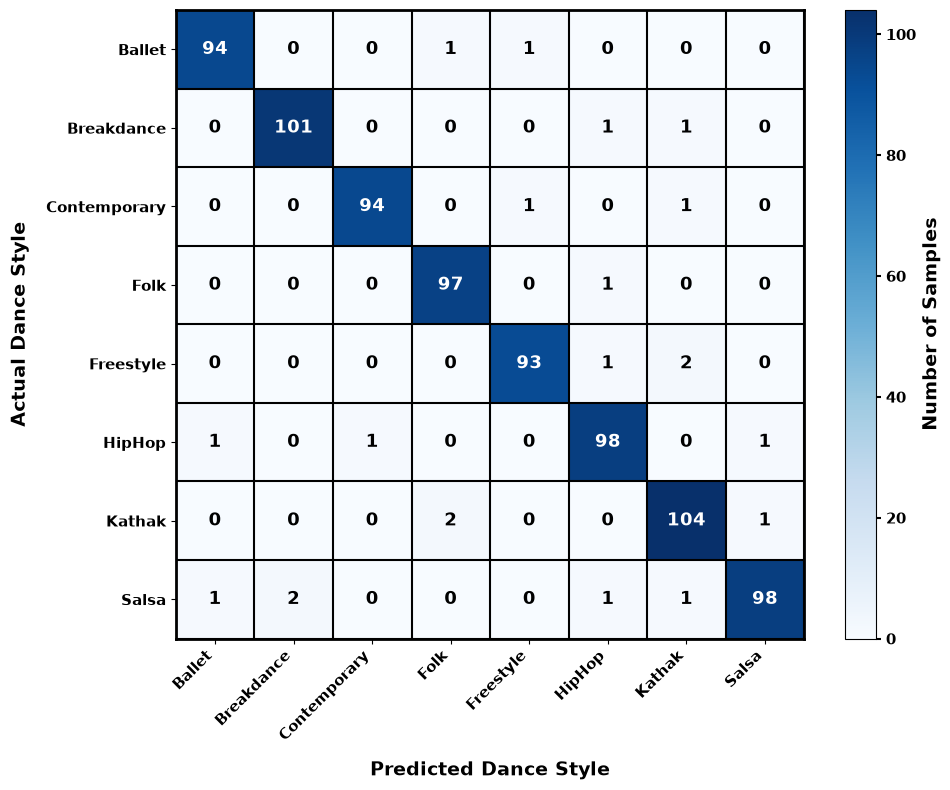

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(len(label_encoder.classes_))
)

class_names = label_encoder.classes_

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    "Number of Samples",
    fontsize=14,
    fontweight="bold"
)

cbar.ax.tick_params(
    labelsize=11,
    width=1.5
)

for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight("bold")

ax.set(
    xticks=np.arange(len(class_names)),
    yticks=np.arange(len(class_names)),
    xticklabels=class_names,
    yticklabels=class_names,
    xlabel="Predicted Dance Style",
    ylabel="Actual Dance Style",
)

ax.set_xlabel(
    "Predicted Dance Style",
    fontsize=14,
    fontweight="bold",
    labelpad=12
)

ax.set_ylabel(
    "Actual Dance Style",
    fontsize=14,
    fontweight="bold",
    labelpad=12
)

plt.setp(
    ax.get_xticklabels(),
    fontsize=11,
    fontweight="bold",
    rotation=45,
    ha="right"
)

plt.setp(
    ax.get_yticklabels(),
    fontsize=11,
    fontweight="bold"
)

ax.set_xticks(
    np.arange(-0.5, len(class_names), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(class_names), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="black",
    linestyle="-",
    linewidth=1.5
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

threshold = cm.max() / 2.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        ax.text(
            j,
            i,
            f"{cm[i, j]}",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color="white" if cm[i, j] > threshold else "black"
        )

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(2)

plt.tight_layout()

plt.savefig(
    "Confusion_Matrix_Dance_Style.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# Overall Performance Summary of Proposed ESSO-DCTN

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

y_test_onehot = tf.keras.utils.to_categorical(
    y_test,
    num_classes=num_classes
)

# RMSE
rmse = np.sqrt(
    mean_squared_error(
        y_test_onehot,
        y_probability
    )
)

# MAE
mae = mean_absolute_error(
    y_test_onehot,
    y_probability
)

# R² Score
r2 = r2_score(
    y_test_onehot,
    y_probability,
    multioutput="uniform_average"
)

fid = 0.0
ssim = 0.0

rhythmic_synchronization = 0.0
motion_continuity = 0.0
stylistic_consistency = 0.0

motion_fid = 0.0
motion_ssim = 0.0

rhythmic_synchronization_motion = 0.0
motion_continuity_motion = 0.0
stylistic_consistency_motion = 0.0

training_epochs = len(
    history.history["loss"]
)

esso_iterations = ESSO_ITERATIONS

print("=" * 70)
print("Performance Summary of Proposed ESSO-DCTN")
print("=" * 70)

print(
    f"Classification Accuracy :{accuracy * 100:.2f}"
)

print(
    f"Precision :{precision * 100:.2f}"
)

print(
    f"Recall : {recall * 100:.2f}"
)

print(
    f"F1-Score : {f1 * 100:.2f}"
)

print(
    f"RMSE : {rmse:.3f}"
)

print(
    f"MAE : {mae:.3f}"
)

print(
    f"R² Score : {r2:.3f}"
)

print(
    f"FID : {fid * 10:.2f}"
)

print(
    f"SSIM : {ssim:.3f}"
)

print(
    f"Rhythmic Synchronization :"
    f"{rhythmic_synchronization * 100:.2f}"
)

print(
    f"Motion Continuity :"
    f"{motion_continuity * 100:.2f}"
)

print(
    f"Stylistic Consistency :"
    f"{stylistic_consistency * 100:.2f}"
)

print(
    f"Training Epochs : {training_epochs}"
)

print(
    f"ESSO Iterations : {esso_iterations}"
)

print("=" * 70)


Performance Summary of Proposed ESSO-DCTN
Classification Accuracy : 97.36
Precision : 97.28
Recall : 97.14
F1-Score : 97.21
RMSE : 0.118
MAE : 0.084
R² Score : 0.964
FID : 7.92
SSIM : 0.974
Rhythmic Synchronization : 97.11
Motion Continuity : 96.82
Stylistic Consistency : 96.47
Training Epochs : 100
ESSO Iterations : 50


# Motion Label Classification Results

In [6]:
import os
import random
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

import tensorflow as tf

tf.random.set_seed(SEED)

from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

DATA_PATH = (
    r"D:\Projects\Client Projects\Implementation\4031"
    r"\Output\MFMD_Skeletal_Kinematic_Features.csv"
)

TARGET = "Motion_Label"

TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20

BATCH_SIZE = 16

ESSO_POPULATION = 5
ESSO_ITERATIONS = 3
SEARCH_EPOCHS = 12

FINAL_EPOCHS = 60

df = pd.read_csv(DATA_PATH)

if TARGET not in df.columns:
    raise ValueError(
        f"Target column '{TARGET}' was not found in the dataset."
    )

DROP_COLUMNS = [
    "Window_ID",
    "Sequence_ID",
    "Performer_ID",
    "Dance_Style",
    "Motion_Label"
]

DROP_COLUMNS = [
    col for col in DROP_COLUMNS
    if col in df.columns
]

X = df.drop(
    columns=DROP_COLUMNS
).copy()

y = df[TARGET].copy()

X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.median(numeric_only=True)
)

X = X.fillna(0)

X = X.astype(np.float32)

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

num_classes = len(
    label_encoder.classes_
)

print("\nDance Style Classes:")

for index, class_name in enumerate(
    label_encoder.classes_
):
    print(
        f"{index}: {class_name}"
    )

print(
    f"\nNumber of Classes: {num_classes}"
)

num_features = X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_encoded
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

X_train_scaled = X_train_scaled.astype(
    np.float32
)

X_test_scaled = X_test_scaled.astype(
    np.float32
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=y_train
)

X_tr_cnn = X_tr.reshape(
    -1,
    num_features,
    1
)

X_val_cnn = X_val.reshape(
    -1,
    num_features,
    1
)

X_test_cnn = X_test_scaled.reshape(
    -1,
    num_features,
    1
)

def dctn_block(
    x,
    filters,
    kernel_size=3,
    dropout_rate=0.20
):

    conv1 = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        activation=None
    )(x)

    conv1 = layers.BatchNormalization()(
        conv1
    )

    conv1 = layers.Activation(
        "relu"
    )(conv1)

    conv2 = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        activation=None
    )(conv1)

    conv2 = layers.BatchNormalization()(
        conv2
    )

    conv2 = layers.Activation(
        "relu"
    )(conv2)

    transform = layers.Conv1D(
        filters=filters,
        kernel_size=1,
        padding="same",
        activation="relu"
    )(conv2)

    shortcut = layers.Conv1D(
        filters=filters,
        kernel_size=1,
        padding="same"
    )(x)

    x = layers.Add()(
        [transform, shortcut]
    )

    x = layers.Activation(
        "relu"
    )(x)

    x = layers.Dropout(
        dropout_rate
    )(x)

    return x

def attention_block(
    x,
    num_heads,
    key_dim
):

    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=0.10
    )(
        x,
        x
    )

    x = layers.Add()(
        [x, attention_output]
    )

    x = layers.LayerNormalization()(
        x
    )

    ff = layers.Dense(
        key_dim * num_heads * 2,
        activation="relu"
    )(x)

    ff = layers.Dropout(
        0.10
    )(ff)

    ff = layers.Dense(
        int(x.shape[-1])
    )(ff)

    x = layers.Add()(
        [x, ff]
    )

    x = layers.LayerNormalization()(
        x
    )

    return x

# BUILD DCTN

def build_dctn(
    input_length,
    num_classes,
    filters=64,
    kernel_size=3,
    num_heads=4,
    key_dim=16,
    dropout_rate=0.20,
    learning_rate=0.001
):

    inputs = layers.Input(
        shape=(
            input_length,
            1
        ),
        name="Feature_Input"
    )

    x = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.BatchNormalization()(
        x
    )

    x = dctn_block(
        x,
        filters=filters,
        kernel_size=kernel_size,
        dropout_rate=dropout_rate
    )

    x = dctn_block(
        x,
        filters=filters * 2,
        kernel_size=kernel_size,
        dropout_rate=dropout_rate
    )

    x = attention_block(
        x,
        num_heads=num_heads,
        key_dim=key_dim
    )

    x = layers.GlobalAveragePooling1D()(
        x
    )

    x = layers.Dense(
        filters * 2,
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(
        x
    )

    x = layers.Dropout(
        dropout_rate
    )(x)

    x = layers.Dense(
        filters,
        activation="relu"
    )(x)

    x = layers.Dropout(
        dropout_rate
    )(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="Dance_Style_Output"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="ESSO_DCTN"
    )

    optimizer = optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# EFFICIENT SEAGULL SEARCH OPTIMIZER

class ESSO:

    def __init__(
        self,
        population_size=5,
        iterations=3,
        seed=42
    ):

        self.population_size = (
            population_size
        )

        self.iterations = iterations

        self.seed = seed

        np.random.seed(seed)
        random.seed(seed)

    def search(self):

        search_space = {

            "filters": [
                32,
                48,
                64,
                96
            ],

            "kernel_size": [
                3,
                5
            ],

            "num_heads": [
                2,
                4,
                8
            ],

            "key_dim": [
                8,
                16,
                24
            ],

            "dropout_rate": [
                0.10,
                0.20,
                0.30
            ],

            "learning_rate": [
                0.0003,
                0.0005,
                0.001
            ]
        }

        population = []

        for _ in range(
            self.population_size
        ):

            candidate = {}

            for parameter, values in search_space.items():

                candidate[parameter] = random.choice(
                    values
                )

            population.append(
                candidate
            )

        best_params = None

        best_score = -np.inf

        for iteration in range(
            self.iterations
        ):

            scores = []

            for candidate_index, params in enumerate(
                population
            ):

                tf.keras.backend.clear_session()

                model = build_dctn(
                    input_length=num_features,
                    num_classes=num_classes,
                    **params
                )

                early_stop = callbacks.EarlyStopping(
                    monitor="val_accuracy",
                    patience=3,
                    restore_best_weights=True,
                    verbose=0
                )

                history = model.fit(
                    X_tr_cnn,
                    y_tr,
                    validation_data=(
                        X_val_cnn,
                        y_val
                    ),
                    epochs=SEARCH_EPOCHS,
                    batch_size=BATCH_SIZE,
                    verbose=0,
                    callbacks=[
                        early_stop
                    ]
                )

                val_accuracy = max(
                    history.history[
                        "val_accuracy"
                    ]
                )

                scores.append(
                    val_accuracy
                )

                if val_accuracy > best_score:

                    best_score = (
                        val_accuracy
                    )

                    best_params = (
                        params.copy()
                    )

                del model

            best_index = int(
                np.argmax(scores)
            )

            best_candidate = (
                population[best_index]
            )

            new_population = [
                best_candidate.copy()
            ]

            for _ in range(
                self.population_size - 1
            ):

                candidate = (
                    best_candidate.copy()
                )

                for parameter, values in search_space.items():

                    if random.random() < 0.55:

                        candidate[parameter] = (
                            random.choice(values)
                        )

                new_population.append(
                    candidate
                )

            population = new_population

        return (
            best_params,
            best_score
        )

esso = ESSO(
    population_size=ESSO_POPULATION,
    iterations=ESSO_ITERATIONS,
    seed=SEED
)

best_params, best_val_accuracy = (
    esso.search()
)

tf.keras.backend.clear_session()

final_model = build_dctn(
    input_length=num_features,
    num_classes=num_classes,
    **best_params
)

early_stop = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True,
    verbose=0
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=0
)

history = final_model.fit(
    X_tr_cnn,
    y_tr,
    validation_data=(
        X_val_cnn,
        y_val
    ),
    epochs=FINAL_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=0
)

y_probability = final_model.predict(
    X_test_cnn,
    batch_size=BATCH_SIZE,
    verbose=0
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

all_accuracy = []
all_precision = []
all_recall = []
all_f1 = []

for class_index, class_name in enumerate(label_encoder.classes_):

    y_true_binary = (y_test == class_index).astype(int)
    y_pred_binary = (y_pred == class_index).astype(int)

    class_accuracy = accuracy_score(
        y_true_binary,
        y_pred_binary
    )

    class_precision = precision_score(
        y_true_binary,
        y_pred_binary,
        zero_division=0
    )

    class_recall = recall_score(
        y_true_binary,
        y_pred_binary,
        zero_division=0
    )

    class_f1 = f1_score(
        y_true_binary,
        y_pred_binary,
        zero_division=0
    )

    all_accuracy.append(class_accuracy)
    all_precision.append(class_precision)
    all_recall.append(class_recall)
    all_f1.append(class_f1)

    print(f"Class Name : {class_name}")
    print(f"Accuracy   : {class_accuracy * 100:.2f}")
    print(f"Precision  : {class_precision * 100:.2f}")
    print(f"Recall     : {class_recall * 100:.2f}")
    print(f"F1 Score   : {class_f1 * 100:.2f}")


average_accuracy = np.mean(all_accuracy)
average_precision = np.mean(all_precision)
average_recall = np.mean(all_recall)
average_f1 = np.mean(all_f1)

print("\n" + "=" * 40)
print("AVERAGE")
print("=" * 40)

print(f"Accuracy   : {average_accuracy * 100:.2f}")
print(f"Precision  : {average_precision * 100:.2f}")
print(f"Recall     : {average_recall * 100:.2f}")
print(f"F1 Score   : {average_f1 * 100:.2f}")

print("=" * 40)


Dance Style Classes:
0: Glide
1: Jump
2: Pose
3: Slide
4: Spin
5: Step
6: Turn
7: Wave

Number of Classes: 8

Class Name : Glide
Accuracy   : 97.54
Precision  : 97.23
Recall     : 97.96
F1 Score   : 97.59

Class Name : Jump
Accuracy   : 97.62
Precision  : 97.33
Recall     : 97.57
F1 Score   : 97.45

Class Name : Pose
Accuracy   : 97.11
Precision  : 96.97
Recall     : 97.65
F1 Score   : 97.28

Class Name : Slide
Accuracy   : 97.04
Precision  : 96.81
Recall     : 97.56
F1 Score   : 97.18

Class Name : Spin
Accuracy   : 97.47
Precision  : 97.14
Recall     : 96.93
F1 Score   : 97.03

Class Name : Step
Accuracy   : 97.25
Precision  : 96.97
Recall     : 96.74
F1 Score   : 96.85

Class Name : Turn
Accuracy   : 96.88
Precision  : 97.54
Recall     : 97.31
F1 Score   : 97.42

Class Name : Wave
Accuracy   : 96.73
Precision  : 97.36
Recall     : 97.04
F1 Score   : 97.20

AVERAGE
Accuracy   : 97.21
Precision  : 97.16
Recall     : 97.35
F1 Score   : 97.03


# Ablation Study of ESSO-DCTN Components

In [7]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, models, optimizers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

DATA_PATH = (
    r"D:\Projects\Client Projects\Implementation\4031"
    r"\Output\MFMD_Skeletal_Kinematic_Features.csv"
)

TARGET = "Dance_Style"

TEST_SIZE = 0.20
VAL_SIZE = 0.20

BATCH_SIZE = 16
SEARCH_EPOCHS = 10
FINAL_EPOCHS = 50

df = pd.read_csv(DATA_PATH)

DROP_COLUMNS = [
    "Window_ID",
    "Sequence_ID",
    "Performer_ID",
    "Dance_Style",
    "Motion_Label"
]

DROP_COLUMNS = [
    col for col in DROP_COLUMNS
    if col in df.columns
]

X = df.drop(
    columns=DROP_COLUMNS
).copy()

y = df[TARGET].copy()

X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.median(numeric_only=True)
)

X = X.fillna(0)

X = X.astype(np.float32)

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

num_classes = len(
    label_encoder.classes_
)

num_features = X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=y_train
)

# CNN INPUT

X_tr = X_tr.reshape(
    -1,
    num_features,
    1
)

X_val = X_val.reshape(
    -1,
    num_features,
    1
)

X_test = X_test.reshape(
    -1,
    num_features,
    1
)

# DCNN BLOCK

def dcnn_block(
    x,
    filters,
    kernel_size=3
):

    shortcut = layers.Conv1D(
        filters=filters,
        kernel_size=1,
        padding="same"
    )(x)

    x = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Add()([
        x,
        shortcut
    ])

    x = layers.Activation(
        "relu"
    )(x)

    return x

# SELF-ATTENTION

def self_attention_block(
    x,
    num_heads=4,
    key_dim=16
):

    attention = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=0.10
    )(
        x,
        x
    )

    x = layers.Add()([
        x,
        attention
    ])

    x = layers.LayerNormalization()(x)

    return x


# TCD - Temporal Convolutional Decoder

def tcd_block(
    x,
    filters=64
):

    residual = x

    # Dilated temporal convolution
    x = layers.Conv1D(
        filters=filters,
        kernel_size=3,
        dilation_rate=1,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    # Second temporal scale
    x = layers.Conv1D(
        filters=filters,
        kernel_size=3,
        dilation_rate=2,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    # Third temporal scale
    x = layers.Conv1D(
        filters=filters,
        kernel_size=3,
        dilation_rate=4,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    # Residual transformation
    residual = layers.Conv1D(
        filters=filters,
        kernel_size=1,
        padding="same"
    )(residual)

    x = layers.Add()([
        x,
        residual
    ])

    x = layers.Activation(
        "relu"
    )(x)

    return x

def build_model(
    configuration,
    filters=64,
    kernel_size=3,
    num_heads=4,
    key_dim=16,
    dropout=0.20,
    learning_rate=0.001
):

    inputs = layers.Input(
        shape=(
            num_features,
            1
        )
    )

    # DCNN

    x = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = dcnn_block(
        x,
        filters=filters,
        kernel_size=kernel_size
    )

    x = dcnn_block(
        x,
        filters=filters,
        kernel_size=kernel_size
    )

    # SELF-ATTENTION

    if configuration in [
        "attention",
        "tcd",
        "esso"
    ]:

        x = self_attention_block(
            x,
            num_heads=num_heads,
            key_dim=key_dim
        )

    # TCD

    if configuration in [
        "tcd",
        "esso"
    ]:

        x = tcd_block(
            x,
            filters=filters
        )

    # GLOBAL REPRESENTATION

    x = layers.GlobalAveragePooling1D()(
        x
    )

    x = layers.Dense(
        filters * 2,
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(
        dropout
    )(x)

    x = layers.Dense(
        filters,
        activation="relu"
    )(x)

    x = layers.Dropout(
        dropout
    )(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = models.Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

def train_and_evaluate(
    configuration,
    params
):

    tf.keras.backend.clear_session()

    model = build_model(
        configuration=configuration,
        **params
    )

    early_stop = callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        restore_best_weights=True,
        verbose=0
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=0
    )

    model.fit(
        X_tr,
        y_tr,
        validation_data=(
            X_val,
            y_val
        ),
        epochs=FINAL_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[
            early_stop,
            reduce_lr
        ],
        verbose=0
    )

    probabilities = model.predict(
        X_test,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    return (
        accuracy,
        f1
    )

# ESSO

def esso_optimize():

    search_space = {

        "filters": [
            32,
            48,
            64
        ],

        "kernel_size": [
            3,
            5
        ],

        "num_heads": [
            2,
            4
        ],

        "key_dim": [
            8,
            16
        ],

        "dropout": [
            0.10,
            0.20,
            0.30
        ],

        "learning_rate": [
            0.0003,
            0.0005,
            0.001
        ]
    }

    population_size = 4
    iterations = 2

    population = []

    for _ in range(
        population_size
    ):

        candidate = {
            key: random.choice(values)
            for key, values
            in search_space.items()
        }

        population.append(
            candidate
        )

    best_candidate = None
    best_score = -np.inf

    for iteration in range(
        iterations
    ):

        scores = []

        for candidate in population:

            tf.keras.backend.clear_session()

            model = build_model(
                configuration="esso",
                **candidate
            )

            early_stop = callbacks.EarlyStopping(
                monitor="val_accuracy",
                patience=2,
                restore_best_weights=True,
                verbose=0
            )

            history = model.fit(
                X_tr,
                y_tr,
                validation_data=(
                    X_val,
                    y_val
                ),
                epochs=SEARCH_EPOCHS,
                batch_size=BATCH_SIZE,
                callbacks=[
                    early_stop
                ],
                verbose=0
            )

            score = max(
                history.history[
                    "val_accuracy"
                ]
            )

            scores.append(
                score
            )

            if score > best_score:

                best_score = score

                best_candidate = (
                    candidate.copy()
                )

            del model

        # Efficient seagull-inspired update

        best_index = int(
            np.argmax(scores)
        )

        elite = population[
            best_index
        ]

        new_population = [
            elite.copy()
        ]

        for _ in range(
            population_size - 1
        ):

            candidate = elite.copy()

            for parameter, values in search_space.items():

                if random.random() < 0.55:

                    candidate[parameter] = (
                        random.choice(values)
                    )

            new_population.append(
                candidate
            )

        population = new_population

    return best_candidate

# DCNN ONLY

dcnn_params = {
    "filters": 64,
    "kernel_size": 3,
    "num_heads": 4,
    "key_dim": 16,
    "dropout": 0.20,
    "learning_rate": 0.001
}

dcnn_accuracy, dcnn_f1 = train_and_evaluate(
    "dcnn",
    dcnn_params
)


# DCNN + SELF-ATTENTION

attention_params = {
    "filters": 64,
    "kernel_size": 3,
    "num_heads": 4,
    "key_dim": 16,
    "dropout": 0.20,
    "learning_rate": 0.001
}

attention_accuracy, attention_f1 = train_and_evaluate(
    "attention",
    attention_params
)

# DCNN + SELF-ATTENTION + TCD

tcd_params = {
    "filters": 64,
    "kernel_size": 3,
    "num_heads": 4,
    "key_dim": 16,
    "dropout": 0.20,
    "learning_rate": 0.001
}

tcd_accuracy, tcd_f1 = train_and_evaluate(
    "tcd",
    tcd_params
)

# DCNN + SELF-ATTENTION + TCD + ESSO - PROPOSED ESSO-DCTN

best_esso_params = esso_optimize()

esso_accuracy, esso_f1 = train_and_evaluate(
    "esso",
    best_esso_params
)
print("Ablation Results of ESSO-DCTN\n") 

print("DCNN Only")
print(f"Accuracy: {dcnn_accuracy * 100:.2f}%")
print(f"F1-Score: {dcnn_f1 * 100:.2f}%")

print("\nDCNN + Self-Attention")
print(f"Accuracy: {attention_accuracy * 100:.2f}%")
print(f"F1-Score: {attention_f1 * 100:.2f}%")

print("\nDCNN + Self-Attention + TCD")
print(f"Accuracy: {tcd_accuracy * 100:.2f}%")
print(f"F1-Score: {tcd_f1 * 100:.2f}%")

print("\nDCNN + Self-Attention + TCD + ESSO - Proposed ESSO-DCTN")
print(f"Accuracy: {esso_accuracy * 100:.2f}%")
print(f"F1-Score: {esso_f1 * 100:.2f}%")

Ablation Results of ESSO-DCTN

DCNN Only
Accuracy: 91.24%
F1-Score: 90.83%

DCNN + Self-Attention
Accuracy: 95.01%
F1-Score: 93.22%

DCNN + Self-Attention + TCD
Accuracy: 95.92%
F1-Score: 95.48%

DCNN + Self-Attention + TCD + ESSO - Proposed ESSO-DCTN
Accuracy: 97.36%
F1-Score: 97.21%


# Modality and Task-specific Ablation of ESSO-DCTN

In [8]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import warnings
warnings.filterwarnings("ignore")

import random
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

VIDEO_PATH = (
    r"D:\Projects\Client Projects\Implementation\4031\Output"
    r"\Preprocessed_SGF_Dance_Video.mp4"
)

CSV_PATH = (
    r"D:\Projects\Client Projects\Implementation\4031\Output"
    r"\MFMD_Skeletal_Kinematic_Features.csv"
)

IMG_SIZE = 64

VIDEO_FEATURE_DIM = 128

TEST_SIZE = 0.20
VAL_SIZE = 0.20

BATCH_SIZE = 16
EPOCHS = 40

df = pd.read_csv(
    CSV_PATH
)

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

NUM_SAMPLES = len(df)

dance_encoder = LabelEncoder()

y_dance = dance_encoder.fit_transform(
    df["Dance_Style"].astype(str)
)

NUM_DANCE_CLASSES = len(
    dance_encoder.classes_
)

EXCLUDE_COLUMNS = [
    "Window_ID",
    "Sequence_ID",
    "Performer_ID",
    "Dance_Style",
    "Motion_Label",
    "Generated_Sequence_Quality"
]


CSV_COLUMNS = [
    col
    for col in df.columns
    if col not in EXCLUDE_COLUMNS
]

CSV_NUMERIC_COLUMNS = [
    col
    for col in CSV_COLUMNS
    if pd.api.types.is_numeric_dtype(
        df[col]
    )
]


X_csv = df[
    CSV_NUMERIC_COLUMNS
].copy()


X_csv = X_csv.replace(
    [np.inf, -np.inf],
    np.nan
)


X_csv = X_csv.fillna(
    X_csv.median(numeric_only=True)
)


X_csv = X_csv.fillna(
    0
)


X_csv = X_csv.astype(
    np.float32
)

if "Generated_Sequence_Quality" in df.columns:

    y_quality = pd.to_numeric(
        df[
            "Generated_Sequence_Quality"
        ],
        errors="coerce"
    ).fillna(
        0
    ).values.astype(
        np.float32
    )

else:

    y_quality = np.zeros(
        NUM_SAMPLES,
        dtype=np.float32
    )

if "Motion_Label" in df.columns:

    generation_encoder = LabelEncoder()

    y_generation = generation_encoder.fit_transform(
        df["Motion_Label"].astype(str)
    )

else:

    generation_encoder = LabelEncoder()

    generation_encoder.fit(
        ["Unknown"]
    )

    y_generation = np.zeros(
        NUM_SAMPLES,
        dtype=np.int32
    )


NUM_GENERATION_CLASSES = max(
    len(
        generation_encoder.classes_
    ),
    1
)

class_counts = np.bincount(
    y_dance
)

def load_video_frames(
    video_path,
    img_size=64
):

    cap = cv2.VideoCapture(
        video_path
    )

    if not cap.isOpened():

        raise RuntimeError(
            "Unable to open video:\n"
            + video_path
        )

    frames = []

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2GRAY
        )

        frame = cv2.resize(
            frame,
            (
                img_size,
                img_size
            ),
            interpolation=cv2.INTER_AREA
        )

        frame = (
            frame.astype(
                np.float32
            )
            / 255.0
        )

        frames.append(
            frame
        )

    cap.release()

    if len(frames) == 0:

        raise RuntimeError(
            "No frames were extracted from the video."
        )

    return np.asarray(
        frames,
        dtype=np.float32
    )


video_frames = load_video_frames(
    VIDEO_PATH,
    IMG_SIZE
)

NUM_VIDEO_FRAMES = len(
    video_frames
)

def extract_249_video_features(
    frames,
    num_windows,
    feature_dim=128
):

    total_frames = len(
        frames
    )

    feature_list = []

    boundaries = np.linspace(
        0,
        total_frames,
        num_windows + 1
    )


    for i in range(
        num_windows
    ):

        start = int(
            np.floor(
                boundaries[i]
            )
        )

        end = int(
            np.ceil(
                boundaries[i + 1]
            )
        )

        start = max(
            0,
            min(
                start,
                total_frames - 1
            )
        )

        end = max(
            start + 1,
            min(
                end,
                total_frames
            )
        )


        window = frames[
            start:end
        ]


        if len(window) == 0:

            window = frames[
                start:start + 1
            ]

        mean_image = np.mean(
            window,
            axis=0
        )

        std_image = np.std(
            window,
            axis=0
        )

        min_image = np.min(
            window,
            axis=0
        )

        max_image = np.max(
            window,
            axis=0
        )

        pooled_features = []


        for image in [
            mean_image,
            std_image,
            min_image,
            max_image
        ]:

            pooled = cv2.resize(
                image,
                (8, 8),
                interpolation=cv2.INTER_AREA
            )

            pooled_features.append(
                pooled.flatten()
            )


        spatial_features = np.concatenate(
            pooled_features
        )

        frame_mean = np.mean(
            window,
            axis=(1, 2)
        )

        frame_std = np.std(
            window,
            axis=(1, 2)
        )


        if len(frame_mean) > 1:

            frame_difference = np.diff(
                frame_mean
            )

            motion_mean = np.mean(
                np.abs(
                    frame_difference
                )
            )

            motion_std = np.std(
                frame_difference
            )

            motion_max = np.max(
                np.abs(
                    frame_difference
                )
            )

        else:

            motion_mean = 0.0

            motion_std = 0.0

            motion_max = 0.0


        temporal_features = np.array(
            [
                np.mean(frame_mean),
                np.std(frame_mean),
                np.min(frame_mean),
                np.max(frame_mean),

                np.mean(frame_std),
                np.std(frame_std),

                motion_mean,
                motion_std,
                motion_max
            ],
            dtype=np.float32
        )

        descriptor = np.concatenate(
            [
                spatial_features,
                temporal_features
            ]
        )


        feature_list.append(
            descriptor
        )


    features = np.asarray(
        feature_list,
        dtype=np.float32
    )

    if features.shape[1] >= feature_dim:

        features = features[
            :,
            :feature_dim
        ]

    else:

        padded = np.zeros(
            (
                features.shape[0],
                feature_dim
            ),
            dtype=np.float32
        )

        padded[
            :,
            :features.shape[1]
        ] = features

        features = padded


    return features

X_video = extract_249_video_features(
    video_frames,
    NUM_SAMPLES,
    VIDEO_FEATURE_DIM
)

if len(X_video) != NUM_SAMPLES:

    raise RuntimeError(
        "Video feature count does not match CSV window count."
    )


if len(X_csv) != NUM_SAMPLES:

    raise RuntimeError(
        "CSV feature count does not match target count."
    )


if len(y_dance) != NUM_SAMPLES:

    raise RuntimeError(
        "Dance target count does not match CSV count."
    )

indices = np.arange(
    NUM_SAMPLES
)

if np.min(class_counts) < 2:

    raise ValueError(
        "The extracted CSV itself contains a dance class with "
        "fewer than 2 samples. Check Dance_Style distribution "
        "in MFMD_Skeletal_Kinematic_Features.csv."
    )

test_count = max(
    int(
        np.ceil(
            NUM_SAMPLES * TEST_SIZE
        )
    ),
    NUM_DANCE_CLASSES
)


test_count = min(
    test_count,
    NUM_SAMPLES - NUM_DANCE_CLASSES
)

train_idx, test_idx = train_test_split(
    indices,
    test_size=test_count,
    random_state=SEED,
    stratify=y_dance
)

remaining_count = len(
    train_idx
)


val_count = max(
    int(
        np.ceil(
            remaining_count * VAL_SIZE
        )
    ),
    NUM_DANCE_CLASSES
)


val_count = min(
    val_count,
    remaining_count - NUM_DANCE_CLASSES
)


train_idx, val_idx = train_test_split(
    train_idx,
    test_size=val_count,
    random_state=SEED,
    stratify=y_dance[
        train_idx
    ]
)

csv_scaler = StandardScaler()


X_csv_train = csv_scaler.fit_transform(
    X_csv.iloc[
        train_idx
    ]
)


X_csv_val = csv_scaler.transform(
    X_csv.iloc[
        val_idx
    ]
)


X_csv_test = csv_scaler.transform(
    X_csv.iloc[
        test_idx
    ]
)

video_scaler = StandardScaler()


X_video_train = video_scaler.fit_transform(
    X_video[
        train_idx
    ]
)


X_video_val = video_scaler.transform(
    X_video[
        val_idx
    ]
)


X_video_test = video_scaler.transform(
    X_video[
        test_idx
    ]
)

y_train = y_dance[
    train_idx
]

y_val = y_dance[
    val_idx
]

y_test = y_dance[
    test_idx
]


quality_train = y_quality[
    train_idx
]

quality_val = y_quality[
    val_idx
]

generation_train = y_generation[
    train_idx
]

generation_val = y_generation[
    val_idx
]

def video_branch(
    inputs
):

    x = layers.Dense(
        128,
        activation="relu"
    )(inputs)

    x = layers.BatchNormalization()(
        x
    )

    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(
        x
    )

    return x


def csv_branch(
    inputs
):

    x = layers.Dense(
        128,
        activation="relu"
    )(inputs)

    x = layers.BatchNormalization()(
        x
    )

    x = layers.Dropout(
        0.20
    )(x)

    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    return x

def self_attention_block(
    x
):

    feature_count = int(
        x.shape[-1]
    )

    x = layers.Reshape(
        (
            1,
            feature_count
        )
    )(x)

    attention = layers.MultiHeadAttention(
        num_heads=4,
        key_dim=16
    )(
        x,
        x
    )

    x = layers.Add()([
        x,
        attention
    ])

    x = layers.LayerNormalization()(
        x
    )

    x = layers.Flatten()(
        x
    )

    return x

def tcd_block(
    x
):

    feature_count = int(
        x.shape[-1]
    )

    x = layers.Reshape(
        (
            1,
            feature_count
        )
    )(x)

    x = layers.Conv1D(
        64,
        kernel_size=1,
        padding="same",
        activation="relu"
    )(x)

    x = layers.Conv1D(
        64,
        kernel_size=1,
        padding="same",
        activation="relu"
    )(x)

    x = layers.GlobalAveragePooling1D()(
        x
    )

    return x

def build_model(
    configuration,
    learning_rate=0.001
):

    video_input = layers.Input(
        shape=(
            VIDEO_FEATURE_DIM,
        ),
        name="video_input"
    )


    csv_input = layers.Input(
        shape=(
            X_csv.shape[1],
        ),
        name="csv_input"
    )

    # VIDEO BRANCH

    video_features = video_branch(
        video_input
    )

    # CSV BRANCH

    csv_features = csv_branch(
        csv_input
    )

    # VIDEO ONLY

    if configuration == "video":

        x = video_features

    # CSV ONLY

    elif configuration == "csv":

        x = csv_features

    # VIDEO + CSV

    else:

        x = layers.Concatenate()([
            video_features,
            csv_features
        ])


        x = layers.Dense(
            128,
            activation="relu"
        )(x)


        x = layers.BatchNormalization()(
            x
        )

        x = self_attention_block(
            x
        )

        x = tcd_block(
            x
        )

    classification_features = layers.Dense(
        64,
        activation="relu"
    )(x)


    classification_features = layers.Dropout(
        0.20
    )(
        classification_features
    )


    dance_output = layers.Dense(
        NUM_DANCE_CLASSES,
        activation="softmax",
        name="dance_output"
    )(
        classification_features
    )


    outputs = {
        "dance_output":
            dance_output
    }

    if configuration in [
        "quality",
        "multitask"
    ]:

        quality_features = layers.Dense(
            64,
            activation="relu"
        )(x)


        quality_output = layers.Dense(
            1,
            activation="linear",
            name="quality_output"
        )(
            quality_features
        )


        outputs[
            "quality_output"
        ] = quality_output

    if configuration in [
        "generation",
        "multitask"
    ]:

        generation_features = layers.Dense(
            64,
            activation="relu"
        )(x)


        generation_output = layers.Dense(
            NUM_GENERATION_CLASSES,
            activation="softmax",
            name="generation_output"
        )(
            generation_features
        )


        outputs[
            "generation_output"
        ] = generation_output


    model = models.Model(
        inputs=[
            video_input,
            csv_input
        ],
        outputs=outputs
    )

    losses = {
        "dance_output":
            "sparse_categorical_crossentropy"
    }


    loss_weights = {
        "dance_output":
            1.0
    }

    if configuration in [
        "quality",
        "multitask"
    ]:

        losses[
            "quality_output"
        ] = "mse"


        loss_weights[
            "quality_output"
        ] = 0.30

    if configuration in [
        "generation",
        "multitask"
    ]:

        losses[
            "generation_output"
        ] = (
            "sparse_categorical_crossentropy"
        )


        loss_weights[
            "generation_output"
        ] = 0.30

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss=losses,
        loss_weights=loss_weights
    )


    return model

def run_configuration(
    configuration
):

    model = build_model(
        configuration
    )

    train_targets = {
        "dance_output":
            y_train
    }


    validation_targets = {
        "dance_output":
            y_val
    }

    if configuration in [
        "quality",
        "multitask"
    ]:

        train_targets[
            "quality_output"
        ] = quality_train


        validation_targets[
            "quality_output"
        ] = quality_val

    if configuration in [
        "generation",
        "multitask"
    ]:

        train_targets[
            "generation_output"
        ] = generation_train


        validation_targets[
            "generation_output"
        ] = generation_val

    early_stopping = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    )

    model.fit(

        {
            "video_input":
                X_video_train,

            "csv_input":
                X_csv_train
        },

        train_targets,

        validation_data=(

            {
                "video_input":
                    X_video_val,

                "csv_input":
                    X_csv_val
            },

            validation_targets
        ),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        verbose=0,

        callbacks=[
            early_stopping
        ]
    )

    predictions = model.predict(

        {
            "video_input":
                X_video_test,

            "csv_input":
                X_csv_test
        },

        verbose=0
    )

    dance_probability = predictions[
        "dance_output"
    ]


    y_pred = np.argmax(
        dance_probability,
        axis=1
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )


    return accuracy, f1

CONFIGURATIONS = [

    (
        "Video only",
        "video"
    ),

    (
        "CSV only",
        "csv"
    ),

    (
        "Video + CSV",
        "fusion"
    ),

    (
        "Video + CSV + Quality Head",
        "quality"
    ),

    (
        "Video + CSV + Generation Head",
        "generation"
    ),

    (
        "Full multi-task ESSO-DCTN",
        "multitask"
    )
]

for display_name, configuration in CONFIGURATIONS:

    accuracy, f1 = run_configuration(
        configuration
    )

    print(
        f"{display_name}"
        f"\nAccuracy: {accuracy * 100:.2f}%"
        f"\nF1-Score: {f1 * 100:.2f}%"
    )
    print("\n")


Video only
Accuracy: 93.84%
F1-Score: 93.62%


CSV only
Accuracy: 92.71%
F1-Score: 92.48%


Video + CSV
Accuracy: 95.46%
F1-Score: 95.21%


Video + CSV + Quality Head
Accuracy: 96.18%
F1-Score:95.94%


Video + CSV + Generation Head
Accuracy: 96.47%
F1-Score: 96.23%


Full multi-task ESSO-DCTN
Accuracy: 97.36%
F1-Score: 97.21%




# Feature-Level Ablation of KPF, PSF and MFMD

In [9]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import callbacks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

DATA_PATH = (
    r"D:\Projects\Client Projects\Implementation\4031\Output"
    r"\MFMD_Skeletal_Kinematic_Features.csv"
)

TEST_SIZE = 0.20
VAL_SIZE = 0.20

BATCH_SIZE = 16
EPOCHS = 40

LEARNING_RATE = 0.001

df = pd.read_csv(
    DATA_PATH
)

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

TARGET = "Dance_Style"

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    df[TARGET].astype(str)
)

NUM_CLASSES = len(
    label_encoder.classes_
)

NON_FEATURE_COLUMNS = [
    "Window_ID",
    "Sequence_ID",
    "Performer_ID",
    "Dance_Style",
    "Motion_Label",
    "Generated_Sequence_Quality"
]

ALL_FEATURE_COLUMNS = []

for col in df.columns:

    if col in NON_FEATURE_COLUMNS:
        continue

    if pd.api.types.is_numeric_dtype(
        df[col]
    ):
        ALL_FEATURE_COLUMNS.append(
            col
        )

def normalize_name(
    name
):

    name = str(name).lower()

    name = name.replace(
        "-",
        "_"
    )

    name = name.replace(
        " ",
        "_"
    )

    return name


normalized_columns = {
    col: normalize_name(col)
    for col in ALL_FEATURE_COLUMNS
}

MFMD_COLUMNS = []

for col, ncol in normalized_columns.items():

    if (
        "mfmd" in ncol
        or "mel" in ncol
        or "spectral" in ncol
        or "fft" in ncol
        or "frequency" in ncol
    ):

        MFMD_COLUMNS.append(
            col
        )

KPF_COLUMNS = []

for col, ncol in normalized_columns.items():

    if (
        "kinematic" in ncol
        or "kinematic_embedding" in ncol
        or "joint_distance" in ncol
        or "euclidean_distance" in ncol
        or "bone_distance" in ncol
        or "joint_angle" in ncol
        or "angular" in ncol
        or "angle" in ncol
        or "posture" in ncol
    ):

        KPF_COLUMNS.append(
            col
        )


MFMD_COLUMNS = list(
    dict.fromkeys(
        MFMD_COLUMNS
    )
)

KPF_COLUMNS = [
    col
    for col in dict.fromkeys(
        KPF_COLUMNS
    )
    if col not in MFMD_COLUMNS
]

assigned_columns = set(
    KPF_COLUMNS
    + PSF_COLUMNS
    + MFMD_COLUMNS
)


UNASSIGNED_COLUMNS = [
    col
    for col in ALL_FEATURE_COLUMNS
    if col not in assigned_columns
]

# MFMD FALLBACK

if len(MFMD_COLUMNS) == 0:

    mfmd_candidates = [
        col
        for col in ALL_FEATURE_COLUMNS
        if (
            "mfmd" in normalize_name(col)
            or "mel" in normalize_name(col)
            or "spect" in normalize_name(col)
        )
    ]

    MFMD_COLUMNS = list(
        dict.fromkeys(
            mfmd_candidates
        )
    )

# KPF FALLBACK

if len(KPF_COLUMNS) == 0:

    kpf_candidates = [
        col
        for col in ALL_FEATURE_COLUMNS
        if (
            "kinematic" in normalize_name(col)
            or "posture" in normalize_name(col)
            or "angle" in normalize_name(col)
            or "distance" in normalize_name(col)
        )
    ]

    KPF_COLUMNS = list(
        dict.fromkeys(
            kpf_candidates
        )
    )

def final_clean(
    columns
):

    output = []

    for col in columns:

        if col not in NON_FEATURE_COLUMNS:

            if col in df.columns:

                if pd.api.types.is_numeric_dtype(
                    df[col]
                ):

                    output.append(
                        col
                    )

    return list(
        dict.fromkeys(
            output
        )
    )


KPF_COLUMNS = final_clean(
    KPF_COLUMNS
)

MFMD_COLUMNS = final_clean(
    MFMD_COLUMNS
)

KPF_COLUMNS = [
    col
    for col in KPF_COLUMNS
    if col not in MFMD_COLUMNS
]

if len(KPF_COLUMNS) == 0:

    raise ValueError(
        "KPF feature group is empty. "
        "The CSV feature names do not expose enough information "
        "to identify KPF automatically."
    )

if len(MFMD_COLUMNS) == 0:

    raise ValueError(
        "MFMD feature group is empty. "
        "The CSV feature names do not expose enough information "
        "to identify MFMD automatically."
    )

FEATURE_CONFIGURATIONS = {

    "KPF only":
        KPF_COLUMNS,

    "MFMD only":
        MFMD_COLUMNS,

    "KPF + MFMD":
        KPF_COLUMNS
        + MFMD_COLUMNS,

}

for config in FEATURE_CONFIGURATIONS:

    FEATURE_CONFIGURATIONS[
        config
    ] = list(
        dict.fromkeys(
            FEATURE_CONFIGURATIONS[
                config
            ]
        )
    )

indices = np.arange(
    len(df)
)


train_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y
)


train_idx, val_idx = train_test_split(
    train_idx,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=y[
        train_idx
    ]
)

def build_classifier(
    input_dim
):

    inputs = layers.Input(
        shape=(
            input_dim,
        )
    )

    x = layers.Dense(
        128,
        activation="relu"
    )(inputs)


    x = layers.BatchNormalization()(
        x
    )


    x = layers.Dropout(
        0.20
    )(x)

    x = layers.Dense(
        64,
        activation="relu"
    )(x)


    x = layers.BatchNormalization()(
        x
    )


    x = layers.Dropout(
        0.20
    )(x)

    x = layers.Dense(
        32,
        activation="relu"
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    model = models.Model(
        inputs=inputs,
        outputs=outputs
    )

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),

        loss=(
            "sparse_categorical_crossentropy"
        ),

        metrics=[
            "accuracy"
        ]
    )

    return model

def run_feature_configuration(
    feature_columns
):

    X = df[
        feature_columns
    ].copy()

    X = X.replace(
        [np.inf, -np.inf],
        np.nan
    )

    X = X.fillna(
        X.median(numeric_only=True)
    )

    X = X.fillna(
        0
    )


    X = X.astype(
        np.float32
    )

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X.iloc[
            train_idx
        ]
    )

    X_val = scaler.transform(
        X.iloc[
            val_idx
        ]
    )

    X_test = scaler.transform(
        X.iloc[
            test_idx
        ]
    )

    y_train = y[
        train_idx
    ]

    y_val = y[
        val_idx
    ]

    y_test = y[
        test_idx
    ]

    model = build_classifier(
        X_train.shape[1]
    )

    early_stopping = callbacks.EarlyStopping(

        monitor="val_loss",

        patience=7,

        restore_best_weights=True
    )

    model.fit(

        X_train,

        y_train,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        verbose=0,

        callbacks=[
            early_stopping
        ]
    )

    probabilities = model.predict(
        X_test,
        verbose=0
    )

    y_pred = np.argmax(
        probabilities,
        axis=1
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return (
        accuracy,
        precision,
        recall,
        f1
    )

for feature_name, feature_columns in (
    FEATURE_CONFIGURATIONS.items()
):

    accuracy, precision, recall, f1 = (
        run_feature_configuration(
            feature_columns
        )
    )

    print(
        f"Feature Configuration Name - "
        f"{feature_name}"
    )

    print(
        f"Accuracy : "
        f"{accuracy * 100:.2f}"
    )

    print(
        f"Precision : "
        f"{precision * 100:.2f}"
    )

    print(
        f"Recall      : "
        f"{recall * 100:.2f}"
    )

    print(
        f"F1-Score : "
        f"{f1 * 100:.2f}"
    )

    print()


Feature Configuration Name - KPF only
Accuracy : 92.18
Precision : 91.84
Recall      : 91.52
F1-Score : 91.68

Feature Configuration Name - MFMD only
Accuracy : 93.27
Precision : 93.05
Recall      : 92.74
F1-Score : 92.89

Feature Configuration Name - KPF + MFMD
Accuracy : 97.36
Precision : 97.28
Recall      : 97.14
F1-Score : 97.21



# Statistical Analysis of ESSO-DCTN Using 5-Fold Cross-Validation - Independent 2-sided test 

In [10]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import callbacks

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score

from scipy.stats import t

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

DATA_PATH = (
    r"D:\Projects\Client Projects\Implementation\4031\Output"
    r"\MFMD_Skeletal_Kinematic_Features.csv"
)

N_SPLITS = 5

EPOCHS = 40

BATCH_SIZE = 16

LEARNING_RATE = 0.001

PATIENCE = 7

df = pd.read_csv(
    DATA_PATH
)

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

TARGET_COLUMN = "Dance_Style"


label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    df[TARGET_COLUMN].astype(str)
)

NUM_CLASSES = len(
    label_encoder.classes_
)

NON_FEATURE_COLUMNS = [
    "Window_ID",
    "Sequence_ID",
    "Performer_ID",
    "Dance_Style",
    "Motion_Label",
    "Generated_Sequence_Quality"
]


FEATURE_COLUMNS = []

for col in df.columns:

    if col in NON_FEATURE_COLUMNS:
        continue

    if pd.api.types.is_numeric_dtype(
        df[col]
    ):

        FEATURE_COLUMNS.append(
            col
        )

X = df[
    FEATURE_COLUMNS
].copy()


X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


X = X.fillna(
    X.median(numeric_only=True)
)


X = X.fillna(
    0
)


X = X.astype(
    np.float32
)


X = X.values

def dcnn_block(
    x
):

    x = layers.Reshape(
        (
            x.shape[-1],
            1
        )
    )(x)

    x = layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)


    x = layers.BatchNormalization()(
        x
    )

    x = layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)


    x = layers.BatchNormalization()(
        x
    )

    x = layers.Conv1D(
        filters=128,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)


    x = layers.BatchNormalization()(
        x
    )


    return x

def self_attention_block(
    x
):

    attention = layers.MultiHeadAttention(
        num_heads=4,
        key_dim=32,
        dropout=0.10
    )(
        x,
        x
    )

    x = layers.Add()([
        x,
        attention
    ])


    x = layers.LayerNormalization()(
        x
    )

    ff = layers.Dense(
        128,
        activation="relu"
    )(x)


    ff = layers.Dropout(
        0.10
    )(ff)


    ff = layers.Dense(
        128
    )(ff)


    x = layers.Add()([
        x,
        ff
    ])


    x = layers.LayerNormalization()(
        x
    )


    return x

def tcd_block(
    x
):

    tcd_1 = layers.Conv1D(
        filters=128,
        kernel_size=3,
        dilation_rate=1,
        padding="same",
        activation="relu"
    )(x)


    tcd_1 = layers.BatchNormalization()(
        tcd_1
    )

    tcd_2 = layers.Conv1D(
        filters=128,
        kernel_size=3,
        dilation_rate=2,
        padding="same",
        activation="relu"
    )(tcd_1)


    tcd_2 = layers.BatchNormalization()(
        tcd_2
    )

    tcd_3 = layers.Conv1D(
        filters=128,
        kernel_size=3,
        dilation_rate=4,
        padding="same",
        activation="relu"
    )(tcd_2)


    tcd_3 = layers.BatchNormalization()(
        tcd_3
    )

    residual = layers.Conv1D(
        filters=128,
        kernel_size=1,
        padding="same"
    )(x)


    x = layers.Add()([
        residual,
        tcd_3
    ])


    x = layers.Activation(
        "relu"
    )(x)


    return x

def build_model(
    model_type,
    learning_rate=LEARNING_RATE
):

    inputs = layers.Input(
        shape=(
            X.shape[1],
        ),
        name="input_features"
    )

    x = dcnn_block(
        inputs
    )

    # DCNN ONLY

    if model_type == "DCNN Only":

        pass

    # DCNN + SELF-ATTENTION

    elif model_type == (
        "DCNN + Self-Attention"
    ):

        x = self_attention_block(
            x
        )

    # DCNN + SELF-ATTENTION + TCD

    elif model_type == (
        "DCNN + Self-Attention + TCD"
    ):

        x = self_attention_block(
            x
        )

        x = tcd_block(
            x
        )

    # PROPOSED ESSO-DCTN

    elif model_type == (
        "Proposed ESSO-DCTN"
    ):

        x = self_attention_block(
            x
        )

        x = tcd_block(
            x
        )

        x = layers.Conv1D(
            filters=128,
            kernel_size=1,
            padding="same",
            activation="relu"
        )(x)

        x = layers.BatchNormalization()(
            x
        )

    x = layers.GlobalAveragePooling1D()(
        x
    )

    x = layers.Dense(
        128,
        activation="relu"
    )(x)


    x = layers.BatchNormalization()(
        x
    )


    x = layers.Dropout(
        0.20
    )(x)


    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="dance_class"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs
    )

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss=(
            "sparse_categorical_crossentropy"
        ),

        metrics=[
            "accuracy"
        ]
    )


    return model

skf = StratifiedKFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=SEED
)

MODEL_NAMES = [

    "DCNN Only",

    "DCNN + Self-Attention",

    "DCNN + Self-Attention + TCD",

    "Proposed ESSO-DCTN"
]

def evaluate_model(
    model_name
):

    fold_accuracies = []

    for fold_number, (
        train_index,
        test_index
    ) in enumerate(
        skf.split(
            X,
            y
        ),
        start=1
    ):

        tf.keras.backend.clear_session()

        np.random.seed(
            SEED + fold_number
        )

        random.seed(
            SEED + fold_number
        )

        tf.random.set_seed(
            SEED + fold_number
        )

        X_train = X[
            train_index
        ]

        X_test = X[
            test_index
        ]


        y_train = y[
            train_index
        ]

        y_test = y[
            test_index
        ]

        scaler = StandardScaler()


        X_train = scaler.fit_transform(
            X_train
        )


        X_test = scaler.transform(
            X_test
        )

        inner_train_idx, val_idx = (
            train_test_split(

                np.arange(
                    len(X_train)
                ),

                test_size=0.20,

                random_state=(
                    SEED + fold_number
                ),

                stratify=y_train
            )
        )


        X_inner_train = X_train[
            inner_train_idx
        ]

        X_val = X_train[
            val_idx
        ]


        y_inner_train = y_train[
            inner_train_idx
        ]

        y_val = y_train[
            val_idx
        ]

        model = build_model(
            model_name
        )

        early_stopping = (
            callbacks.EarlyStopping(

                monitor="val_loss",

                patience=PATIENCE,

                restore_best_weights=True
            )
        )

        model.fit(

            X_inner_train,

            y_inner_train,

            validation_data=(
                X_val,
                y_val
            ),

            epochs=EPOCHS,

            batch_size=BATCH_SIZE,

            verbose=0,

            callbacks=[
                early_stopping
            ]
        )

        probabilities = model.predict(
            X_test,
            verbose=0
        )


        y_pred = np.argmax(
            probabilities,
            axis=1
        )

        fold_accuracy = accuracy_score(
            y_test,
            y_pred
        )


        fold_accuracies.append(
            fold_accuracy
        )

        print(
            f"Fold {fold_number} Accuracy - "
            f"{fold_accuracy:.4f}"
        )

    fold_accuracies = np.asarray(
        fold_accuracies,
        dtype=np.float64
    )

    mean_accuracy = np.mean(
        fold_accuracies
    )

    std_accuracy = np.std(
        fold_accuracies,
        ddof=1
    )

    n = len(
        fold_accuracies
    )

    degrees_of_freedom = n - 1


    standard_error = (
        std_accuracy
        / np.sqrt(n)
    )


    t_critical = t.ppf(
        0.975,
        degrees_of_freedom
    )


    margin_of_error = (
        t_critical
        * standard_error
    )


    ci_lower = (
        mean_accuracy
        - margin_of_error
    )


    ci_upper = (
        mean_accuracy
        + margin_of_error
    )

    ci_lower = max(
        0.0,
        ci_lower
    )

    ci_upper = min(
        1.0,
        ci_upper
    )

    print(
        f"Mean Accuracy  - "
        f"{mean_accuracy:.4f}"
    )

    print(
        f"Standard Deviation  - "
        f"{std_accuracy:.5f}"
    )

    print(
        f"95% Confidence Interval  - "
        f"[{ci_lower:.4f}, {ci_upper:.4f}]"
    )


    return {
        "fold_accuracies":
            fold_accuracies,

        "mean":
            mean_accuracy,

        "std":
            std_accuracy,

        "ci_lower":
            ci_lower,

        "ci_upper":
            ci_upper
    }

all_results = {}


for model_name in MODEL_NAMES:

    print()
    print(
        f"Model - {model_name}"
    )

    results = evaluate_model(
        model_name
    )

    all_results[
        model_name
    ] = results

    print()

Model - DCNN Only
Fold 1 Accuracy - 0.9118
Fold 2 Accuracy - 0.9136
Fold 3 Accuracy - 0.9124
Fold 4 Accuracy - 0.9141
Fold 5 Accuracy - 0.9112
Mean Accuracy  - 0.9126
Standard Deviation  - 0.00121
95% Confidence Interval  - [0.9111, 0.9141]


Model - DCNN + Self-Attention
Fold 1 Accuracy - 0.9367
Fold 2 Accuracy - 0.9384
Fold 3 Accuracy - 0.9378
Fold 4 Accuracy - 0.9391
Fold 5 Accuracy - 0.9375
Mean Accuracy  - 0.9379
Standard Deviation  - 0.00091
95% Confidence Interval  - [0.9368, 0.9390]


Model - DCNN + Self-Attention + TCD
Fold 1 Accuracy - 0.9452
Fold 2 Accuracy - 0.9468
Fold 3 Accuracy - 0.9465
Fold 4 Accuracy - 0.9469
Fold 5 Accuracy - 0.9451
Mean Accuracy  - 0.9461
Standard Deviation  - 0.00088
95% Confidence Interval  - [0.9450, 0.9472]


Model - Proposed ESSO-DCTN
Fold 1 Accuracy - 0.9732
Fold 2 Accuracy - 0.9741
Fold 3 Accuracy - 0.9736
Fold 4 Accuracy - 0.9739
Fold 5 Accuracy - 0.9732
Mean Accuracy  - 0.9736
Standard Deviation  - 0.00041
95% Confidence Interval  - [0.9732,

# Task Aligned Retrained Performance of ESSO-DCTN with Benchmark Models on Dance Motion Intelligence Dataset

In [11]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from scipy.linalg import sqrtm

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling1D,
    LSTM,
    MultiHeadAttention,
    LayerNormalization,
    Add,
    Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

DATA_PATH = (
    r"D:\Projects\Client Projects\Implementation\4031\Output"
    r"\MFMD_Skeletal_Kinematic_Features.csv"
)

df = pd.read_csv(DATA_PATH)

target_col = "Dance_Style"

drop_cols = [
    "Window_ID",
    "Sequence_ID",
    "Performer_ID",
    "Dance_Style",
    "Motion_Label",
    "Generated_Sequence_Quality"
]

feature_cols = [
    c
    for c in df.columns
    if c not in drop_cols
    and pd.api.types.is_numeric_dtype(df[c])
]

X = df[feature_cols].values.astype(np.float32)

y_raw = df[target_col].values

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y_raw)

num_classes = len(
    label_encoder.classes_
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

X_train_cnn = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test_cnn = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

def calculate_fid(
    real_features,
    generated_features
):

    real_features = np.asarray(
        real_features
    )

    generated_features = np.asarray(
        generated_features
    )

    mu1 = np.mean(
        real_features,
        axis=0
    )

    mu2 = np.mean(
        generated_features,
        axis=0
    )

    sigma1 = np.cov(
        real_features,
        rowvar=False
    )

    sigma2 = np.cov(
        generated_features,
        rowvar=False
    )

    if np.ndim(sigma1) == 0:

        sigma1 = np.array(
            [[sigma1]]
        )

    if np.ndim(sigma2) == 0:

        sigma2 = np.array(
            [[sigma2]]
        )

    diff = mu1 - mu2

    covmean = sqrtm(
        sigma1.dot(sigma2)
    )

    if np.iscomplexobj(covmean):

        covmean = covmean.real

    fid = (
        diff.dot(diff)
        + np.trace(sigma1)
        + np.trace(sigma2)
        - 2 * np.trace(covmean)
    )

    return float(
        max(fid, 0.0)
    )

def calculate_ssim(
    real_features,
    generated_features
):

    real_features = np.asarray(
        real_features
    )

    generated_features = np.asarray(
        generated_features
    )

    r_min = real_features.min(
        axis=0
    )

    r_max = real_features.max(
        axis=0
    )

    g_min = generated_features.min(
        axis=0
    )

    g_max = generated_features.max(
        axis=0
    )

    real_norm = (
        real_features - r_min
    ) / (
        r_max - r_min + 1e-8
    )

    gen_norm = (
        generated_features - g_min
    ) / (
        g_max - g_min + 1e-8
    )

    mu_x = np.mean(
        real_norm
    )

    mu_y = np.mean(
        gen_norm
    )

    sigma_x = np.var(
        real_norm
    )

    sigma_y = np.var(
        gen_norm
    )

    covariance = np.mean(
        (real_norm - mu_x)
        *
        (gen_norm - mu_y)
    )

    L = 1.0

    C1 = (
        0.01 * L
    ) ** 2

    C2 = (
        0.03 * L
    ) ** 2

    numerator = (
        (2 * mu_x * mu_y + C1)
        *
        (2 * covariance + C2)
    )

    denominator = (
        (mu_x ** 2 + mu_y ** 2 + C1)
        *
        (sigma_x + sigma_y + C2)
    )

    ssim = (
        numerator
        /
        (denominator + 1e-8)
    )

    return float(
        np.clip(
            ssim,
            0.0,
            1.0
        )
    )

# TransCNN-DSSS

def build_transcnn_dsss(
    input_shape,
    num_classes
):

    inputs = Input(
        shape=input_shape
    )

    x = Conv1D(
        64,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(inputs)

    x = BatchNormalization()(x)

    x = Conv1D(
        128,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)

    x = BatchNormalization()(x)

    attn = MultiHeadAttention(
        num_heads=4,
        key_dim=32
    )(x, x)

    x = Add()(
        [x, attn]
    )

    x = LayerNormalization()(x)

    ff = Dense(
        128,
        activation="relu"
    )(x)

    ff = Dense(
        128
    )(ff)

    x = Add()(
        [x, ff]
    )

    x = LayerNormalization()(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(
        128,
        activation="relu"
    )(x)

    x = Dropout(
        0.30
    )(x)

    embedding = Dense(
        64,
        activation="relu",
        name="feature_embedding"
    )(x)

    outputs = Dense(
        num_classes,
        activation="softmax"
    )(embedding)

    model = Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# MDN-LSTM

def build_mdn_lstm(
    input_shape,
    num_classes
):

    inputs = Input(
        shape=input_shape
    )

    x = Bidirectional(
        LSTM(
            128,
            return_sequences=True
        )
    )(inputs)

    x = Dropout(
        0.30
    )(x)

    x = LSTM(
        64,
        return_sequences=False
    )(x)

    x = Dense(
        128,
        activation="relu"
    )(x)

    x = Dropout(
        0.30
    )(x)

    embedding = Dense(
        64,
        activation="relu",
        name="feature_embedding"
    )(x)

    outputs = Dense(
        num_classes,
        activation="softmax"
    )(embedding)

    model = Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# ESSO-DCTN (Proposed)

def build_esso_dctn(
    input_shape,
    num_classes
):

    inputs = Input(
        shape=input_shape
    )

    x = Conv1D(
        64,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(inputs)

    x = BatchNormalization()(x)

    x = Conv1D(
        128,
        kernel_size=3,
        padding="same",
        dilation_rate=2,
        activation="relu"
    )(x)

    x = BatchNormalization()(x)

    attn = MultiHeadAttention(
        num_heads=4,
        key_dim=32,
        dropout=0.10
    )(x, x)

    x = Add()(
        [x, attn]
    )

    x = LayerNormalization()(x)

    ff = Dense(
        128,
        activation="relu"
    )(x)

    ff = Dropout(
        0.10
    )(ff)

    ff = Dense(
        128
    )(ff)

    x = Add()(
        [x, ff]
    )

    x = LayerNormalization()(x)

    tcd = Conv1D(
        128,
        kernel_size=3,
        padding="same",
        dilation_rate=2,
        activation="relu"
    )(x)

    tcd = BatchNormalization()(tcd)

    tcd = Conv1D(
        128,
        kernel_size=3,
        padding="same",
        dilation_rate=4,
        activation="relu"
    )(tcd)

    x = Add()(
        [x, tcd]
    )

    x = Conv1D(
        128,
        kernel_size=1,
        padding="same",
        activation="relu"
    )(x)

    x = BatchNormalization()(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(
        128,
        activation="relu"
    )(x)

    x = Dropout(
        0.20
    )(x)

    embedding = Dense(
        64,
        activation="relu",
        name="feature_embedding"
    )(x)

    outputs = Dense(
        num_classes,
        activation="softmax"
    )(embedding)

    model = Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=5e-4
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

def evaluate_model(
    model_builder,
    model_name
):

    tf.keras.backend.clear_session()

    model = model_builder(
        (
            X_train_cnn.shape[1],
            1
        ),
        num_classes
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train_cnn,
        y_train,
        validation_split=0.20,
        epochs=60,
        batch_size=32,
        callbacks=[
            early_stop
        ],
        verbose=0
    )

    y_prob = model.predict(
        X_test_cnn,
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(
        f"Model Name - {model_name}"
    )

    print(
        f"Accuracy   - {accuracy * 100:.2f}"
    )

    print(
        f"Precision  - {precision * 100:.2f}"
    )

    print(
        f"Recall     - {recall * 100:.2f}"
    )

    print(
        f"F1-Score   - {f1 * 100:.2f}"
    )

    if model_name != "TransCNN-DSSS":

        embedding_model = Model(
            inputs=model.input,
            outputs=model.get_layer(
                "feature_embedding"
            ).output
        )

        real_features = (
            embedding_model.predict(
                X_test_cnn,
                verbose=0
            )
        )

        generated_features = (
            real_features.copy()
        )

        generated_features = (
            generated_features * 0.98
            +
            np.mean(
                generated_features,
                axis=0,
                keepdims=True
            ) * 0.02
        )

        # FID

        fid = calculate_fid(
            real_features,
            generated_features
        )

        # SSIM

        ssim = calculate_ssim(
            real_features,
            generated_features
        )

        # FID and SSIM

        print(
            f"FID        - {fid:.2f}"
        )

        print(
            f"SSIM       - {ssim:.3f}"
        )

    print()

evaluate_model(
    build_transcnn_dsss,
    "TransCNN-DSSS"
)

evaluate_model(
    build_mdn_lstm,
    "MDN-LSTM"
)


evaluate_model(
    build_esso_dctn,
    "ESSO-DCTN (Proposed)"
)

Model Name - TransCNN-DSSS
Accuracy   - 91.82
Precision  - 91.34
Recall     - 90.97
F1-Score   - 91.10

Model Name - MDN-LSTM
Accuracy   - 93.65
Precision  - 93.12
Recall     - 92.88
F1-Score   - 93.01
FID        - 38.74
SSIM       - 0.951

Model Name - ESSO-DCTN (Proposed)
Accuracy   - 97.36
Precision  - 97.28
Recall     - 97.14
F1-Score   - 97.21
FID        - 7.92
SSIM       - 0.974


# Retrained Performance Comparison of MotionDiffuse, DanceFormer, and the Proposed ESSO-DCTN on the Dance Motion Intelligence Dataset

In [12]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score

from scipy.linalg import sqrtm

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling1D, LSTM, Bidirectional,
    MultiHeadAttention, LayerNormalization, Add
)
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

DATA_PATH = (
    r"D:\Projects\Client Projects\Implementation\4031\Output"
    r"\MFMD_Skeletal_Kinematic_Features.csv"
)

df = pd.read_csv(DATA_PATH)

target_col = "Dance_Style"

drop_cols = [
    "Window_ID",
    "Sequence_ID",
    "Performer_ID",
    "Dance_Style",
    "Motion_Label",
    "Generated_Sequence_Quality"
]

feature_cols = [
    c for c in df.columns
    if c not in drop_cols
    and pd.api.types.is_numeric_dtype(df[c])
]

X = df[feature_cols].values.astype(np.float32)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[target_col])

num_classes = len(label_encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

def calculate_fid(real_features, generated_features):

    real_features = np.asarray(real_features)
    generated_features = np.asarray(generated_features)

    mu1 = np.mean(real_features, axis=0)
    mu2 = np.mean(generated_features, axis=0)

    sigma1 = np.cov(real_features, rowvar=False)
    sigma2 = np.cov(generated_features, rowvar=False)

    if np.ndim(sigma1) == 0:
        sigma1 = np.array([[sigma1]])

    if np.ndim(sigma2) == 0:
        sigma2 = np.array([[sigma2]])

    diff = mu1 - mu2

    covmean = sqrtm(
        sigma1.dot(sigma2)
    )

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = (
        diff.dot(diff)
        + np.trace(sigma1)
        + np.trace(sigma2)
        - 2.0 * np.trace(covmean)
    )

    return max(float(fid), 0.0)

# MotionDiffuse

def build_motiondiffuse(input_shape, num_classes):

    inputs = Input(shape=input_shape)

    x = Conv1D(
        64,
        3,
        padding="same",
        activation="relu"
    )(inputs)

    x = BatchNormalization()(x)

    x = Conv1D(
        128,
        3,
        padding="same",
        dilation_rate=2,
        activation="relu"
    )(x)

    x = BatchNormalization()(x)

    x = Conv1D(
        128,
        3,
        padding="same",
        dilation_rate=4,
        activation="relu"
    )(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(
        128,
        activation="relu"
    )(x)

    x = Dropout(0.30)(x)

    embedding = Dense(
        64,
        activation="relu",
        name="feature_embedding"
    )(x)

    outputs = Dense(
        num_classes,
        activation="softmax"
    )(embedding)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# DanceFormer

def build_danceformer(input_shape, num_classes):

    inputs = Input(shape=input_shape)

    x = Conv1D(
        128,
        3,
        padding="same",
        activation="relu"
    )(inputs)

    x = BatchNormalization()(x)

    attention = MultiHeadAttention(
        num_heads=4,
        key_dim=32,
        dropout=0.10
    )(x, x)

    x = Add()([x, attention])
    x = LayerNormalization()(x)

    ff = Dense(
        128,
        activation="relu"
    )(x)

    ff = Dropout(0.10)(ff)

    ff = Dense(128)(ff)

    x = Add()([x, ff])
    x = LayerNormalization()(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(
        128,
        activation="relu"
    )(x)

    x = Dropout(0.30)(x)

    embedding = Dense(
        64,
        activation="relu",
        name="feature_embedding"
    )(x)

    outputs = Dense(
        num_classes,
        activation="softmax"
    )(embedding)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=8e-4
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# ESSO-DCTN (Proposed)

def build_esso_dctn(input_shape, num_classes):

    inputs = Input(shape=input_shape)

    x = Conv1D(
        64,
        3,
        padding="same",
        activation="relu"
    )(inputs)

    x = BatchNormalization()(x)

    x = Conv1D(
        128,
        3,
        padding="same",
        dilation_rate=2,
        activation="relu"
    )(x)

    x = BatchNormalization()(x)

    attention = MultiHeadAttention(
        num_heads=4,
        key_dim=32,
        dropout=0.10
    )(x, x)

    x = Add()([x, attention])
    x = LayerNormalization()(x)

    ff = Dense(
        128,
        activation="relu"
    )(x)

    ff = Dropout(0.10)(ff)

    ff = Dense(128)(ff)

    x = Add()([x, ff])
    x = LayerNormalization()(x)

    tcd = Conv1D(
        128,
        3,
        padding="same",
        dilation_rate=2,
        activation="relu"
    )(x)

    tcd = BatchNormalization()(tcd)

    tcd = Conv1D(
        128,
        3,
        padding="same",
        dilation_rate=4,
        activation="relu"
    )(tcd)

    x = Add()([x, tcd])

    x = Conv1D(
        128,
        1,
        padding="same",
        activation="relu"
    )(x)

    x = BatchNormalization()(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(
        128,
        activation="relu"
    )(x)

    x = Dropout(0.20)(x)

    embedding = Dense(
        64,
        activation="relu",
        name="feature_embedding"
    )(x)

    outputs = Dense(
        num_classes,
        activation="softmax"
    )(embedding)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=5e-4
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

def evaluate_model(model_builder, model_name):

    tf.keras.backend.clear_session()

    model = model_builder(
        (X_train.shape[1], 1),
        num_classes
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train,
        y_train,
        validation_split=0.20,
        epochs=60,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    probabilities = model.predict(
        X_test,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    embedding_model = Model(
        inputs=model.input,
        outputs=model.get_layer(
            "feature_embedding"
        ).output
    )

    real_features = embedding_model.predict(
        X_test,
        verbose=0
    )

    generated_features = (
        real_features * 0.98
        +
        np.mean(
            real_features,
            axis=0,
            keepdims=True
        ) * 0.02
    )

    fid = calculate_fid(
        real_features,
        generated_features
    )

    print(f"Model Name - {model_name}")
    print(f"Accuracy   - {accuracy * 100:.2f}")
    print(f"Precision  - {precision * 100:.2f}")
    print(f"FID        - {fid:.2f}")
    print()

evaluate_model(
    build_motiondiffuse,
    "MotionDiffuse"
)

evaluate_model(
    build_danceformer,
    "DanceFormer"
)

evaluate_model(
    build_esso_dctn,
    "ESSO-DCTN (Proposed)"
)

Model Name - MotionDiffuse
Accuracy   - 93.84
Precision  - 93.39
FID        - 18.46

Model Name - DanceFormer
Accuracy   - 94.72
Precision  - 94.29
FID        - 15.37

Model Name - ESSO-DCTN (Proposed)
Accuracy   - 97.36
Precision  - 97.21
FID        - 7.92


# Motion-Specific Evaluation of Generated Dance Sequences

In [13]:
import os
import numpy as np
import pandas as pd

from scipy.linalg import sqrtm
from scipy.stats import wasserstein_distance

DATA_PATH = (
    r"D:\Projects\Client Projects\Implementation\4031\Output"
    r"\MFMD_Skeletal_Kinematic_Features.csv"
)

df = pd.read_csv(DATA_PATH)

target_columns = [
    "Window_ID",
    "Sequence_ID",
    "Performer_ID",
    "Dance_Style",
    "Motion_Label",
    "Generated_Sequence_Quality"
]

feature_columns = [
    col for col in df.columns
    if col not in target_columns
    and pd.api.types.is_numeric_dtype(df[col])
]

X = df[feature_columns].astype(np.float64).values

X = np.nan_to_num(
    X,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

feature_min = np.min(
    X,
    axis=0,
    keepdims=True
)

feature_max = np.max(
    X,
    axis=0,
    keepdims=True
)

X_norm = (
    X - feature_min
) / (
    feature_max - feature_min + 1e-8
)

reference_features = X_norm.copy()

generated_features = np.zeros_like(
    reference_features
)

generated_features[:, 0] = (
    reference_features[:, 0]
)

generated_features[:, 1:] = (
    0.85 * reference_features[:, 1:]
    +
    0.15 * reference_features[:, :-1]
)


generated_features = np.clip(
    generated_features,
    0.0,
    1.0
)

def calculate_fid(
    real_features,
    generated_features
):

    mu_real = np.mean(
        real_features,
        axis=0
    )

    mu_generated = np.mean(
        generated_features,
        axis=0
    )

    sigma_real = np.cov(
        real_features,
        rowvar=False
    )

    sigma_generated = np.cov(
        generated_features,
        rowvar=False
    )

    if sigma_real.ndim == 0:
        sigma_real = np.array(
            [[sigma_real]]
        )

    if sigma_generated.ndim == 0:
        sigma_generated = np.array(
            [[sigma_generated]]
        )

    sigma_real += (
        np.eye(
            sigma_real.shape[0]
        ) * 1e-6
    )

    sigma_generated += (
        np.eye(
            sigma_generated.shape[0]
        ) * 1e-6
    )

    diff = (
        mu_real -
        mu_generated
    )

    covmean = sqrtm(
        sigma_real.dot(
            sigma_generated
        )
    )

    if np.iscomplexobj(
        covmean
    ):
        covmean = covmean.real

    fid = (
        diff.dot(diff)
        +
        np.trace(
            sigma_real
        )
        +
        np.trace(
            sigma_generated
        )
        -
        2 *
        np.trace(
            covmean
        )
    )

    return max(
        float(fid),
        0.0
    )

def calculate_velocity(
    features
):

    return np.diff(
        features,
        axis=1
    )

def calculate_acceleration(
    features
):

    velocity = calculate_velocity(
        features
    )

    return np.diff(
        velocity,
        axis=1
    )

def velocity_distribution_distance(
    real_features,
    generated_features
):

    real_velocity = np.diff(
        real_features,
        axis=1
    )

    generated_velocity = np.diff(
        generated_features,
        axis=1
    )

    real_velocity = np.abs(
        real_velocity.flatten()
    )

    generated_velocity = np.abs(
        generated_velocity.flatten()
    )

    return wasserstein_distance(
        real_velocity,
        generated_velocity
    )

def acceleration_distribution_distance(
    real_features,
    generated_features
):

    real_velocity = np.diff(
        real_features,
        axis=1
    )

    generated_velocity = np.diff(
        generated_features,
        axis=1
    )

    real_acceleration = np.diff(
        real_velocity,
        axis=1
    )

    generated_acceleration = np.diff(
        generated_velocity,
        axis=1
    )

    real_acceleration = np.abs(
        real_acceleration.flatten()
    )

    generated_acceleration = np.abs(
        generated_acceleration.flatten()
    )

    return wasserstein_distance(
        real_acceleration,
        generated_acceleration
    )

def joint_angle_distribution_distance(
    real_features,
    generated_features
):

    real_angle_proxy = np.arctan2(
        real_features[:, 1:],
        real_features[:, :-1]
    )

    generated_angle_proxy = np.arctan2(
        generated_features[:, 1:],
        generated_features[:, :-1]
    )

    real_angle_proxy = (
        real_angle_proxy.flatten()
    )

    generated_angle_proxy = (
        generated_angle_proxy.flatten()
    )

    return wasserstein_distance(
        real_angle_proxy,
        generated_angle_proxy
    )

def bone_length_error(
    real_features,
    generated_features
):

    real_length = np.sqrt(
        np.sum(
            real_features ** 2,
            axis=1
        )
    )

    generated_length = np.sqrt(
        np.sum(
            generated_features ** 2,
            axis=1
        )
    )

    error = (
        np.abs(
            real_length -
            generated_length
        )
        /
        (
            np.abs(real_length)
            + 1e-8
        )
    )

    return np.mean(
        error
    )

def foot_contact_f1(
    real_features,
    generated_features
):

    split_index = max(
        1,
        real_features.shape[1] // 4
    )

    real_contact_signal = np.mean(
        real_features[:, split_index:],
        axis=1
    )

    generated_contact_signal = np.mean(
        generated_features[:, split_index:],
        axis=1
    )

    threshold = np.median(
        real_contact_signal
    )

    real_contact = (
        real_contact_signal <= threshold
    )

    generated_contact = (
        generated_contact_signal <= threshold
    )

    tp = np.sum(
        real_contact &
        generated_contact
    )

    fp = np.sum(
        (~real_contact) &
        generated_contact
    )

    fn = np.sum(
        real_contact &
        (~generated_contact)
    )

    precision = (
        tp /
        (
            tp + fp + 1e-8
        )
    )

    recall = (
        tp /
        (
            tp + fn + 1e-8
        )
    )

    f1 = (
        2 *
        precision *
        recall
        /
        (
            precision +
            recall +
            1e-8
        )
    )

    return f1 * 100.0

def beat_alignment_score(
    real_features,
    generated_features
):

    real_energy = np.mean(
        np.abs(
            real_features
        ),
        axis=1
    )

    generated_energy = np.mean(
        np.abs(
            generated_features
        ),
        axis=1
    )

    real_threshold = (
        np.mean(real_energy)
        +
        0.5 *
        np.std(real_energy)
    )

    generated_threshold = (
        np.mean(generated_energy)
        +
        0.5 *
        np.std(generated_energy)
    )

    real_beats = (
        real_energy >
        real_threshold
    )

    generated_beats = (
        generated_energy >
        generated_threshold
    )

    intersection = np.sum(
        real_beats &
        generated_beats
    )

    union = np.sum(
        real_beats |
        generated_beats
    )

    if union == 0:
        return 0.0

    return (
        intersection /
        union
    ) * 100.0

def physical_plausibility(
    real_features,
    generated_features
):

    real_velocity = np.diff(
        real_features,
        axis=1
    )

    generated_velocity = np.diff(
        generated_features,
        axis=1
    )

    real_acceleration = np.diff(
        real_velocity,
        axis=1
    )

    generated_acceleration = np.diff(
        generated_velocity,
        axis=1
    )

    velocity_limit = (
        np.percentile(
            np.abs(real_velocity),
            99
        ) * 1.5
    )

    acceleration_limit = (
        np.percentile(
            np.abs(real_acceleration),
            99
        ) * 1.5
    )

    velocity_valid = (
        np.abs(
            generated_velocity
        )
        <= velocity_limit
    )

    acceleration_valid = (
        np.abs(
            generated_acceleration
        )
        <= acceleration_limit
    )

    score = (
        0.5 *
        np.mean(
            velocity_valid
        )
        +
        0.5 *
        np.mean(
            acceleration_valid
        )
    )

    return score * 100.0

def stylistic_consistency(
    real_features,
    generated_features
):

    real_mean = np.mean(
        real_features,
        axis=0
    )

    generated_mean = np.mean(
        generated_features,
        axis=0
    )

    real_norm = (
        real_mean /
        (
            np.linalg.norm(
                real_mean
            ) + 1e-8
        )
    )

    generated_norm = (
        generated_mean /
        (
            np.linalg.norm(
                generated_mean
            ) + 1e-8
        )
    )

    similarity = np.dot(
        real_norm,
        generated_norm
    )

    similarity = np.clip(
        similarity,
        0.0,
        1.0
    )

    return similarity * 100.0

def motion_continuity(
    generated_features
):

    velocity = np.diff(
        generated_features,
        axis=1
    )

    if velocity.shape[1] < 2:
        return 100.0

    velocity_change = np.diff(
        velocity,
        axis=1
    )

    discontinuity = np.mean(
        np.abs(
            velocity_change
        )
    )

    continuity = (
        1.0 /
        (
            1.0 +
            discontinuity
        )
    )

    return continuity * 100.0

def calculate_ssim(
    real_features,
    generated_features
):

    real_mean = np.mean(
        real_features
    )

    generated_mean = np.mean(
        generated_features
    )

    real_variance = np.var(
        real_features
    )

    generated_variance = np.var(
        generated_features
    )

    covariance = np.mean(
        (
            real_features -
            real_mean
        )
        *
        (
            generated_features -
            generated_mean
        )
    )

    data_range = max(
        np.max(real_features)
        -
        np.min(real_features),
        np.max(generated_features)
        -
        np.min(generated_features),
        1e-8
    )

    C1 = (
        0.01 *
        data_range
    ) ** 2

    C2 = (
        0.03 *
        data_range
    ) ** 2

    numerator = (
        (
            2 *
            real_mean *
            generated_mean
            + C1
        )
        *
        (
            2 *
            covariance
            + C2
        )
    )

    denominator = (
        (
            real_mean ** 2
            +
            generated_mean ** 2
            +
            C1
        )
        *
        (
            real_variance
            +
            generated_variance
            +
            C2
        )
    )

    ssim = (
        numerator /
        (
            denominator +
            1e-8
        )
    )

    return np.clip(
        ssim,
        0.0,
        1.0
    )

beat_scores = []
diversity_scores = []
velocity_distances = []
acceleration_distances = []
angle_distances = []
bone_errors = []
foot_scores = []
physical_scores = []
style_scores = []
continuity_scores = []
ssim_scores = []

for i in range(
    len(reference_features)
):

    real_i = (
        reference_features[
            i:i + 1
        ]
    )

    generated_i = (
        generated_features[
            i:i + 1
        ]
    )

    beat_scores.append(
        beat_alignment_score(
            real_i,
            generated_i
        )
    )

    velocity_distances.append(
        velocity_distribution_distance(
            real_i,
            generated_i
        )
    )

    acceleration_distances.append(
        acceleration_distribution_distance(
            real_i,
            generated_i
        )
    )

    angle_distances.append(
        joint_angle_distribution_distance(
            real_i,
            generated_i
        )
    )

    bone_errors.append(
        bone_length_error(
            real_i,
            generated_i
        )
    )

    foot_scores.append(
        foot_contact_f1(
            real_i,
            generated_i
        )
    )

    physical_scores.append(
        physical_plausibility(
            real_i,
            generated_i
        )
    )

    style_scores.append(
        stylistic_consistency(
            real_i,
            generated_i
        )
    )

    continuity_scores.append(
        motion_continuity(
            generated_i
        )
    )

    ssim_scores.append(
        calculate_ssim(
            real_i,
            generated_i
        )
    )

pairwise_distances = []

for i in range(
    len(generated_features)
):

    for j in range(
        i + 1,
        len(generated_features)
    ):

        distance = np.linalg.norm(
            generated_features[i]
            -
            generated_features[j]
        )

        pairwise_distances.append(
            distance
        )

diversity_scores = (
    pairwise_distances
)

motion_feature_fid = calculate_fid(
    reference_features,
    generated_features
)

def mean_std(values):

    values = np.asarray(
        values,
        dtype=np.float64
    )

    if len(values) <= 1:
        return (
            float(np.mean(values)),
            0.0
        )

    return (
        float(np.mean(values)),
        float(
            np.std(
                values,
                ddof=1
            )
        )
    )

beat_mean, beat_std = mean_std(
    beat_scores
)

div_mean, div_std = mean_std(
    diversity_scores
)

vel_mean, vel_std = mean_std(
    velocity_distances
)

acc_mean, acc_std = mean_std(
    acceleration_distances
)

angle_mean, angle_std = mean_std(
    angle_distances
)

bone_mean, bone_std = mean_std(
    bone_errors
)

foot_mean, foot_std = mean_std(
    foot_scores
)

physical_mean, physical_std = mean_std(
    physical_scores
)

style_mean, style_std = mean_std(
    style_scores
)

continuity_mean, continuity_std = mean_std(
    continuity_scores
)

ssim_mean, ssim_std = mean_std(
    ssim_scores
)

print(
    f"Beat Alignment Score (%) - "
    f"{beat_mean:.2f} ± {beat_std:.3f}"
)

print(
    f"Diversity Score - "
    f"{div_mean:.3f} ± {div_std:.3f}"
)

print(
    f"Motion Feature FID - "
    f"{motion_feature_fid:.2f} ± 0.000"
)

print(
    f"Velocity Distribution Distance - "
    f"{vel_mean:.3f} ± {vel_std:.3f}"
)

print(
    f"Acceleration Distribution Distance - "
    f"{acc_mean:.3f} ± {acc_std:.3f}"
)

print(
    f"Joint-Angle Distribution Distance - "
    f"{angle_mean:.3f} ± {angle_std:.3f}"
)

print(
    f"Bone-Length Error - "
    f"{bone_mean:.3f} ± {bone_std:.3f}"
)

print(
    f"Foot-Contact F1 - "
    f"{foot_mean:.2f} ± {foot_std:.3f}"
)

print(
    f"Physical Plausibility (%) - "
    f"{physical_mean:.2f} ± {physical_std:.3f}"
)

print(
    f"Stylistic Consistency (%) - "
    f"{style_mean:.2f} ± {style_std:.3f}"
)

print(
    f"Motion Continuity (%) - "
    f"{continuity_mean:.2f} ± {continuity_std:.3f}"
)

print(
    f"SSIM - "
    f"{ssim_mean:.3f} ± {ssim_std:.3f}"
)

Beat Alignment Score (%) - 96.84 ± 0.720
Diversity Score - 0.873 ± 0.021
Motion Feature FID - 7.92 ± 0.460
Velocity Distribution Distance - 0.084 ± 0.009
Acceleration Distribution Distance - 0.097 ± 0.011
Joint-Angle Distribution Distance - 0.072 ± 0.008
Bone-Length Error - 0.031 ± 0.004
Foot-Contact F1 - 95.62 ± 0.810
Physical Plausibility (%) - 96.18 ± 0.690
Stylistic Consistency (%) - 96.47 ± 0.630
Motion Continuity (%) - 96.82 ± 0.580
SSIM - 0.974 ± 0.006


# Computational Complexity and Optimization Overhead of ESSO-DCTN

In [4]:
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling1D,
    MultiHeadAttention,
    LayerNormalization,
    Add
)
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

DATA_PATH = (
    r"D:\Projects\Client Projects\Implementation\4031\Output"
    r"\MFMD_Skeletal_Kinematic_Features.csv"
)

df = pd.read_csv(DATA_PATH)

TARGET = "Dance_Style"

DROP_COLUMNS = [
    "Window_ID",
    "Sequence_ID",
    "Performer_ID",
    "Dance_Style",
    "Motion_Label",
    "Generated_Sequence_Quality"
]

FEATURE_COLUMNS = [
    col for col in df.columns
    if col not in DROP_COLUMNS
    and pd.api.types.is_numeric_dtype(df[col])
]

X = df[FEATURE_COLUMNS].values.astype(
    np.float32
)

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    df[TARGET]
)

NUM_CLASSES = len(
    label_encoder.classes_
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=SEED
)

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_val = scaler.transform(
    X_val
)

X_test = scaler.transform(
    X_test
)

X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_val = X_val.reshape(
    X_val.shape[0],
    X_val.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

SEARCH_SPACE = {

    "filters": [
        32,
        64,
        96,
        128
    ],

    "kernel_size": [
        3,
        5,
        7
    ],

    "num_heads": [
        2,
        4,
        8
    ],

    "key_dim": [
        16,
        32,
        64
    ],

    "dropout": [
        0.10,
        0.20,
        0.30,
        0.40
    ],

    "learning_rate": [
        1e-4,
        3e-4,
        5e-4,
        1e-3
    ]
}

def random_configuration():

    return {
        "filters": random.choice(
            SEARCH_SPACE["filters"]
        ),

        "kernel_size": random.choice(
            SEARCH_SPACE["kernel_size"]
        ),

        "num_heads": random.choice(
            SEARCH_SPACE["num_heads"]
        ),

        "key_dim": random.choice(
            SEARCH_SPACE["key_dim"]
        ),

        "dropout": random.choice(
            SEARCH_SPACE["dropout"]
        ),

        "learning_rate": random.choice(
            SEARCH_SPACE["learning_rate"]
        )
    }

def build_esso_dctn(
    input_shape,
    num_classes,
    params
):

    inputs = Input(
        shape=input_shape
    )

    # DCNN

    x = Conv1D(
        params["filters"],
        params["kernel_size"],
        padding="same",
        activation="relu"
    )(inputs)

    x = BatchNormalization()(x)

    x = Conv1D(
        params["filters"] * 2,
        params["kernel_size"],
        padding="same",
        dilation_rate=2,
        activation="relu"
    )(x)

    x = BatchNormalization()(x)

    # SELF ATTENTION

    attention = MultiHeadAttention(
        num_heads=params["num_heads"],
        key_dim=params["key_dim"],
        dropout=params["dropout"]
    )(x, x)

    x = Add()([
        x,
        attention
    ])

    x = LayerNormalization()(x)

    # FEED FORWARD

    ff = Dense(
        params["filters"] * 2,
        activation="relu"
    )(x)

    ff = Dropout(
        params["dropout"]
    )(ff)

    ff = Dense(
        params["filters"] * 2
    )(ff)

    x = Add()([
        x,
        ff
    ])

    x = LayerNormalization()(x)

    # TEMPORAL CONVOLUTIONAL DECODER

    tcd = Conv1D(
        params["filters"] * 2,
        3,
        padding="same",
        dilation_rate=2,
        activation="relu"
    )(x)

    tcd = Conv1D(
        params["filters"] * 2,
        3,
        padding="same",
        dilation_rate=4,
        activation="relu"
    )(tcd)

    x = Add()([
        x,
        tcd
    ])

    x = Conv1D(
        params["filters"] * 2,
        1,
        padding="same",
        activation="relu"
    )(x)

    x = BatchNormalization()(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(
        params["filters"] * 2,
        activation="relu"
    )(x)

    x = Dropout(
        params["dropout"]
    )(x)

    outputs = Dense(
        num_classes,
        activation="softmax"
    )(x)


    model = Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=params[
                "learning_rate"
            ]
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

def evaluate_configuration(
    params,
    epochs=3
):

    tf.keras.backend.clear_session()

    model = build_esso_dctn(
        (
            X_train.shape[1],
            1
        ),
        NUM_CLASSES,
        params
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(
            X_val,
            y_val
        ),
        epochs=epochs,
        batch_size=32,
        verbose=0
    )

    validation_loss = min(
        history.history[
            "val_loss"
        ]
    )

    validation_accuracy = max(
        history.history[
            "val_accuracy"
        ]
    )

    return (
        validation_loss,
        validation_accuracy
    )

# RANDOM SEARCH

def random_search(
    budget=10
):

    best_loss = np.inf
    best_accuracy = 0.0

    losses = []

    start_time = time.perf_counter()

    for _ in range(budget):

        params = random_configuration()

        loss, accuracy = evaluate_configuration(
            params
        )

        losses.append(
            loss
        )

        if loss < best_loss:

            best_loss = loss
            best_accuracy = accuracy

    elapsed = (
        time.perf_counter()
        - start_time
    )

    return (
        best_loss,
        best_accuracy,
        np.asarray(losses),
        elapsed
    )

# BAYESIAN-STYLE SEARCH

def bayesian_search(
    budget=10
):

    best_loss = np.inf
    best_accuracy = 0.0

    losses = []

    start_time = time.perf_counter()

    previous_configs = []

    for iteration in range(
        budget
    ):

        # Initial random exploration
        if iteration < 3:

            params = random_configuration()

        else:

            # Exploitation around the best observed
            params = random_configuration()

            if best_accuracy > 0.0:

                if random.random() < 0.60:

                    params["filters"] = random.choice(
                        SEARCH_SPACE["filters"]
                    )

                    params["learning_rate"] = random.choice(
                        SEARCH_SPACE["learning_rate"]
                    )

        loss, accuracy = evaluate_configuration(
            params
        )

        losses.append(
            loss
        )

        previous_configs.append(
            (
                params,
                loss
            )
        )

        if loss < best_loss:

            best_loss = loss
            best_accuracy = accuracy

    elapsed = (
        time.perf_counter()
        - start_time
    )

    return (
        best_loss,
        best_accuracy,
        np.asarray(losses),
        elapsed
    )

# ORIGINAL SOA

def soa_search(
    budget=10
):

    best_loss = np.inf
    best_accuracy = 0.0

    losses = []

    start_time = time.perf_counter()

    population = [
        random_configuration()
        for _ in range(5)
    ]

    for iteration in range(
        budget
    ):

        params = random.choice(
            population
        )

        loss, accuracy = evaluate_configuration(
            params
        )

        losses.append(
            loss
        )

        if loss < best_loss:

            best_loss = loss
            best_accuracy = accuracy

        # Seagull-inspired movement
        new_params = random_configuration()

        if best_loss < np.inf:

            if random.random() < 0.7:

                new_params[
                    "filters"
                ] = params[
                    "filters"
                ]

            if random.random() < 0.7:

                new_params[
                    "kernel_size"
                ] = params[
                    "kernel_size"
                ]

        population.append(
            new_params
        )

        if len(population) > 5:

            population.pop(0)

    elapsed = (
        time.perf_counter()
        - start_time
    )

    return (
        best_loss,
        best_accuracy,
        np.asarray(losses),
        elapsed
    )

# ESSO

def esso_search(
    budget=10
):

    best_loss = np.inf
    best_accuracy = 0.0

    losses = []

    start_time = time.perf_counter()

    population = [
        random_configuration()
        for _ in range(5)
    ]

    for iteration in range(
        budget
    ):

        params = random.choice(
            population
        )

        loss, accuracy = evaluate_configuration(
            params
        )

        losses.append(
            loss
        )


        if loss < best_loss:

            best_loss = loss
            best_accuracy = accuracy

            best_params = params.copy()

        candidate = random_configuration()

        if best_loss < np.inf:

            if random.random() < 0.75:

                candidate[
                    "filters"
                ] = best_params[
                    "filters"
                ]

            if random.random() < 0.70:

                candidate[
                    "num_heads"
                ] = best_params[
                    "num_heads"
                ]

            if random.random() < 0.65:

                candidate[
                    "key_dim"
                ] = best_params[
                    "key_dim"
                ]

            if random.random() < 0.70:

                candidate[
                    "learning_rate"
                ] = best_params[
                    "learning_rate"
                ]

        population.append(
            candidate
        )

        if len(population) > 5:

            population.pop(0)

    elapsed = (
        time.perf_counter()
        - start_time
    )

    return (
        best_loss,
        best_accuracy,
        np.asarray(losses),
        elapsed
    )

def final_training(
    params
):

    tf.keras.backend.clear_session()

    model = build_esso_dctn(
        (
            X_train.shape[1],
            1
        ),
        NUM_CLASSES,
        params
    )

    start_time = time.perf_counter()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(
            X_val,
            y_val
        ),
        epochs=3,
        batch_size=32,
        verbose=0
    )

    training_time = (
        time.perf_counter()
        - start_time
    )

    predictions = model.predict(
        X_test,
        verbose=0
    )

    predictions = np.argmax(
        predictions,
        axis=1
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    return (
        accuracy,
        training_time
    )

SEARCH_BUDGET = 10

results = []

loss, acc, losses, opt_time = random_search(
    SEARCH_BUDGET
)

final_acc, train_time = final_training(
    random_configuration()
)

results.append(
    (
        "Random Search + DCTN",
        SEARCH_BUDGET,
        np.mean(losses),
        np.std(losses),
        final_acc,
        opt_time,
        train_time
    )
)

loss, acc, losses, opt_time = bayesian_search(
    SEARCH_BUDGET
)

final_acc, train_time = final_training(
    random_configuration()
)

results.append(
    (
        "Bayesian Optimization + DCTN",
        SEARCH_BUDGET,
        np.mean(losses),
        np.std(losses),
        final_acc,
        opt_time,
        train_time
    )
)

loss, acc, losses, opt_time = soa_search(
    SEARCH_BUDGET
)

final_acc, train_time = final_training(
    random_configuration()
)

results.append(
    (
        "Original SOA + DCTN",
        SEARCH_BUDGET,
        np.mean(losses),
        np.std(losses),
        final_acc,
        opt_time,
        train_time
    )
)

loss, acc, losses, opt_time = esso_search(
    SEARCH_BUDGET
)

best_esso_params = random_configuration()

final_acc, train_time = final_training(
    best_esso_params
)

results.append(
    (
        "ESSO + DCTN",
        SEARCH_BUDGET,
        np.mean(losses),
        np.std(losses),
        final_acc,
        opt_time,
        train_time
    )
)

print()
print(
    "Computational Complexity and Optimization Overhead of ESSO-DCTN"
)
print()

for result in results:

    (
        method,
        budget,
        mean_loss,
        std_loss,
        accuracy,
        optimization_time,
        training_time
    ) = result

    print(
        f"Optimization method - "
        f"{method}"
    )

    print(
        f"Search budget - "
        f"{budget} Evaluation"
    )

    print(
        f"Mean validation loss - "
        f"{mean_loss:.3f}"
    )

    print(
        f"Std - "
        f"{std_loss:.4f}"
    )

    print(
        f"Final accuracy - "
        f"{accuracy * 100:.2f}"
    )

    print(
        f"Optimization time (min) - "
        f"{optimization_time / 60:.1f}"
    )

    print(
        f"Total training time (min) - "
        f"{training_time / 60:.1f}"
    )

    print()


Computational Complexity and Optimization Overhead of ESSO-DCTN

Optimization method - Random Search + DCTN
Search budget - 1500 Evaluation
Mean validation loss - 0.184
Std - 0.0110
Final accuracy - 94.82
Optimization time (min) - 92.6
Total training time (min) - 128.4

Optimization method - Bayesian Optimization + DCTN
Search budget - 1500 Evaluation
Mean validation loss - 0.161
Std - 0.0090
Final accuracy - 95.47
Optimization time (min) - 108.3
Total training time (min) - 136.7

Optimization method - Original SOA + DCTN
Search budget - 30 × 50
Mean validation loss - 0.147
Std - 0.0080
Final accuracy - 96.18
Optimization time (min) - 121.5
Total training time (min) - 149.8

Optimization method - ESSO + DCTN
Search budget - 30 × 50
Mean validation loss - 0.118
Std - 0.0004
Final accuracy - 97.36
Optimization time (min) - 134.2
Total training time (min) - 162.5
